In [1]:

!pip install open_clip_torch captum --quiet
!pip install transformers --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 108.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but

In [2]:
# ============================================================
# 1.1 Imports
# ============================================================

# Standard Library
import os
import gc
import json
import copy
import math
import time
import random
import pickle
import warnings
import re
from pathlib import Path
from collections import OrderedDict
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple, Any

# Scientific Computing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Image Processing
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader,
)

from torch.optim import AdamW

from torch.optim.lr_scheduler import (
    CosineAnnealingLR,
)

from torch.cuda.amp import (
    autocast,
    GradScaler,
)

# TorchVision
import torchvision.transforms as T

# HuggingFace
from transformers import (
    AutoTokenizer,
    AutoModel,
)

# OpenCLIP
import open_clip

# Metrics
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    classification_report,
    hamming_loss,
)

# Explainability
from captum.attr import (
    IntegratedGradients,
    LayerIntegratedGradients,
)

# Progress Bar
from tqdm.auto import tqdm

# Misc
warnings.filterwarnings("ignore")

print("✅ All imports successful.")

✅ All imports successful.


In [3]:
# --------------------------------------------------------------------
# 2.1 Configuration Dictionary & Directory Initialization
# --------------------------------------------------------------------

CONFIG = {

    # ── Paths ───────────────────────────────────────────────────────
    "image_root":
        "/kaggle/input/datasets/"
        "simhadrisadaram/mimic-cxr-dataset/"
        "official_data_iccv_final/files",

    "train_csv":
        "/kaggle/input/datasets/"
        "vedantkulkarni14/labeled-mimic-cxr/"
        "labeled_mimic_cxr/"
        "mimic_final_labeled_train.csv",

    "val_csv":
        "/kaggle/input/datasets/"
        "vedantkulkarni14/labeled-mimic-cxr/"
        "labeled_mimic_cxr/"
        "mimic_final_labeled_validate.csv",

    "output_dir":
        "/kaggle/working/artifacts",

    # ── Labels ─────────────────────────────────────────────────────
    "disease_labels": [

        "No Finding",
        "Cardiomegaly",
        "Edema",
        "Pleural Effusion",
        "Pneumonia",
        "Pneumothorax",
    ],

    "num_classes": 6,

    # ── Encoders ───────────────────────────────────────────────────
    "biomed_clip_model":
        "hf-hub:microsoft/"
        "BiomedCLIP-PubMedBERT_256-vit_base_patch16_224",

    "text_model_name":
        "emilyalsentzer/Bio_ClinicalBERT",

    # ── Embedding Dimensions ──────────────────────────────────────
    "image_embed_dim": 512,

    "text_embed_dim": 768,

    "fused_dim": None,   # computed automatically

    # ── Text ──────────────────────────────────────────────────────
    "max_text_len": 256,

    # ── Image ─────────────────────────────────────────────────────
    "image_size": 224,

    # ── Training ──────────────────────────────────────────────────
    "epochs": 18,

    "batch_size": 32,

    "num_workers": 0,

    "patience": 5,

    "max_grad_norm": 1.0,

    "ema_decay": 0.999,

    "mixed_precision": True,

    "tta_enabled": True,

    # ── Learning Rates ────────────────────────────────────────────
    "lr_image_encoder": 5e-6,

    "lr_text_encoder": 2e-5,

    "lr_fusion_head": 1e-4,

    "weight_decay": 1e-4,

    # ── Loss ──────────────────────────────────────────────────────
    "focal_gamma": 2.0,

    "weight_clip_min": 0.5,

    "weight_clip_max": 20.0,

    # ── Freeze Strategy ───────────────────────────────────────────
    "biomed_clip_freeze_blocks": 6,

    "bert_freeze_layers": 10,

    # ── GradCAM ───────────────────────────────────────────────────
    "gradcam_block_idx": -2,

    # ── Threshold Optimization ────────────────────────────────────
    "threshold_start": 0.10,

    "threshold_end": 0.90,

    "threshold_steps": 81,

    # ── Reproducibility ───────────────────────────────────────────
    "seed": 42,

    # ── Runtime ───────────────────────────────────────────────────
    "device":
        "cuda"
        if torch.cuda.is_available()
        else "cpu",

    "multi_gpu":
        torch.cuda.device_count() > 1,
}

# Compute fusion dimension automatically
CONFIG["fused_dim"] = (
    CONFIG["image_embed_dim"]
    + CONFIG["text_embed_dim"]
)

# Create output directory
OUTPUT_DIR = Path(CONFIG["output_dir"])

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("✅ Configuration loaded.\n")

for k, v in CONFIG.items():
    print(f"{k:<35}: {v}")

✅ Configuration loaded.

image_root                         : /kaggle/input/datasets/simhadrisadaram/mimic-cxr-dataset/official_data_iccv_final/files
train_csv                          : /kaggle/input/datasets/vedantkulkarni14/labeled-mimic-cxr/labeled_mimic_cxr/mimic_final_labeled_train.csv
val_csv                            : /kaggle/input/datasets/vedantkulkarni14/labeled-mimic-cxr/labeled_mimic_cxr/mimic_final_labeled_validate.csv
output_dir                         : /kaggle/working/artifacts
disease_labels                     : ['No Finding', 'Cardiomegaly', 'Edema', 'Pleural Effusion', 'Pneumonia', 'Pneumothorax']
num_classes                        : 6
biomed_clip_model                  : hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224
text_model_name                    : emilyalsentzer/Bio_ClinicalBERT
image_embed_dim                    : 512
text_embed_dim                     : 768
fused_dim                          : 1280
max_text_len                       : 25

In [4]:
# ============================================================
# 2.2 Seed Everything for Reproducibility
# ============================================================

def seed_everything(seed: int = 42):
    """
    Seed all random number generators for full reproducibility.
    """

    random.seed(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # CuDNN settings
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Additional PyTorch reproducibility
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass

    print(f"✅ Seed set to {seed}")


seed_everything(CONFIG["seed"])

✅ Seed set to 42


In [5]:
# ============================================================
# 2.3 Device Detection
# ============================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

NUM_GPUS = torch.cuda.device_count()

print("🖥️ Environment Information")
print("=" * 60)

print(f"Device            : {DEVICE}")
print(f"CUDA Available    : {torch.cuda.is_available()}")
print(f"Number of GPUs    : {NUM_GPUS}")

if torch.cuda.is_available():

    for i in range(NUM_GPUS):

        props = torch.cuda.get_device_properties(i)

        print(f"\nGPU {i}")
        print("-" * 40)
        print(f"Name              : {props.name}")
        print(f"Total Memory      : {props.total_memory / 1e9:.1f} GB")
        print(f"Multi Processor   : {props.multi_processor_count}")

else:

    print("\n⚠️ Running on CPU.")

print("=" * 60)

🖥️ Environment Information
Device            : cuda
CUDA Available    : True
Number of GPUs    : 2

GPU 0
----------------------------------------
Name              : Tesla T4
Total Memory      : 15.6 GB
Multi Processor   : 40

GPU 1
----------------------------------------
Name              : Tesla T4
Total Memory      : 15.6 GB
Multi Processor   : 40


In [6]:
# ============================================================
# 3.1 Load CSVs
# ============================================================

import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# Verify CSV existence
# ------------------------------------------------------------

assert Path(CONFIG["train_csv"]).exists(), \
    f"Train CSV not found:\n{CONFIG['train_csv']}"

assert Path(CONFIG["val_csv"]).exists(), \
    f"Validation CSV not found:\n{CONFIG['val_csv']}"

print("✅ CSV files found.")

# ------------------------------------------------------------
# Load CSVs
# ------------------------------------------------------------

print("\n⏳ Loading CSV files...")

df_train_raw = pd.read_csv(
    CONFIG["train_csv"]
)

df_val_raw = pd.read_csv(
    CONFIG["val_csv"]
)

print("\n✅ CSV loading complete.\n")

# ------------------------------------------------------------
# Dataset Statistics
# ------------------------------------------------------------

print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)

print(f"📊 Raw train samples      : {len(df_train_raw):,}")
print(f"📊 Raw validation samples : {len(df_val_raw):,}")

print(
    f"\n💾 Train memory usage : "
    f"{df_train_raw.memory_usage(deep=True).sum()/1e6:.2f} MB"
)

print(
    f"💾 Val memory usage   : "
    f"{df_val_raw.memory_usage(deep=True).sum()/1e6:.2f} MB"
)

# ------------------------------------------------------------
# Duplicate checks
# ------------------------------------------------------------

if "study_id" in df_train_raw.columns:

    train_dups = (
        df_train_raw["study_id"]
        .duplicated()
        .sum()
    )

    val_dups = (
        df_val_raw["study_id"]
        .duplicated()
        .sum()
    )

    print(
        f"\n🔍 Duplicate train studies : "
        f"{train_dups:,}"
    )

    print(
        f"🔍 Duplicate val studies   : "
        f"{val_dups:,}"
    )

print("=" * 70)

# ------------------------------------------------------------
# Column inspection
# ------------------------------------------------------------

print("\n📋 Train Columns:\n")

for i, col in enumerate(
    df_train_raw.columns,
    start=1,
):
    print(f"{i:>2}. {col}")

print("\n🔍 Train sample:")
display(df_train_raw.head(2))

✅ CSV files found.

⏳ Loading CSV files...

✅ CSV loading complete.

DATASET OVERVIEW
📊 Raw train samples      : 45,224
📊 Raw validation samples : 338

💾 Train memory usage : 82.04 MB
💾 Val memory usage   : 0.67 MB

🔍 Duplicate train studies : 0
🔍 Duplicate val studies   : 0

📋 Train Columns:

 1. subject_id
 2. study_id
 3. image_path
 4. report
 5. selected_view
 6. No Finding
 7. Cardiomegaly
 8. Edema
 9. Pleural Effusion
10. Pneumonia
11. Pneumothorax

🔍 Train sample:


,subject_id,study_id,image_path,report,selected_view,No Finding,Cardiomegaly,Edema,Pleural Effusion,Pneumonia,Pneumothorax
0,10000032,s50414267,/kaggle/input/datasets/simhadrisadaram/mimic-c...,"findings: there is no focal consolidation, ple...","['PA', 'LATERAL', 'AP']",0,0,0,1,1,1
1,10000764,s57375967,/kaggle/input/datasets/simhadrisadaram/mimic-c...,findings: pa and lateral views of the chest pr...,"['AP', 'LATERAL']",0,0,0,0,1,0


In [7]:
# ============================================================
# 3.2 Missing Data Analysis
# ============================================================

print("=" * 70)
print("MISSING VALUE ANALYSIS")
print("=" * 70)

for name, df in [
    ("Train", df_train_raw),
    ("Validation", df_val_raw),
]:

    print(f"\n{name} Set")

    missing = df.isnull().sum()

    for col, cnt in missing.items():

        pct = 100 * cnt / len(df)

        print(
            f"{col:<25}"
            f"{cnt:>8,} "
            f"({pct:.2f}%)"
        )

print("=" * 70)

# Empty reports

train_empty_reports = (
    df_train_raw["report"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

val_empty_reports = (
    df_val_raw["report"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print(f"\nEmpty train reports : {train_empty_reports:,}")
print(f"Empty val reports   : {val_empty_reports:,}")

MISSING VALUE ANALYSIS

Train Set
subject_id                      0 (0.00%)
study_id                        0 (0.00%)
image_path                      0 (0.00%)
report                          0 (0.00%)
selected_view                   0 (0.00%)
No Finding                      0 (0.00%)
Cardiomegaly                    0 (0.00%)
Edema                           0 (0.00%)
Pleural Effusion                0 (0.00%)
Pneumonia                       0 (0.00%)
Pneumothorax                    0 (0.00%)

Validation Set
subject_id                      0 (0.00%)
study_id                        0 (0.00%)
image_path                      0 (0.00%)
report                          0 (0.00%)
selected_view                   0 (0.00%)
No Finding                      0 (0.00%)
Cardiomegaly                    0 (0.00%)
Edema                           0 (0.00%)
Pleural Effusion                0 (0.00%)
Pneumonia                       0 (0.00%)
Pneumothorax                    0 (0.00%)

Empty train reports : 0
E

In [8]:
# ============================================================
# 3.2 Report Cleaning & Dataset Preparation
# ============================================================

def clean_report(text: str) -> str:
    """
    Clean radiology report text.
    """

    if not isinstance(text, str):
        return ""

    text = text.lower()

    # Remove line breaks/tabs
    text = re.sub(r"[\n\r\t]", " ", text)

    # Remove repeated punctuation
    text = re.sub(r"[^\w\s.,:;!?()-]", " ", text)

    # Collapse multiple spaces
    text = re.sub(r"\s+", " ", text)

    text = text.strip()

    return text


def prepare_dataframe(
    df: pd.DataFrame,
    split_name: str,
) -> pd.DataFrame:

    initial_count = len(df)

    print("\n" + "=" * 70)
    print(f"🔧 Preparing {split_name} Split")
    print("=" * 70)

    df = df.copy()

    # ---------------------------------------------------------
    # Clean reports
    # ---------------------------------------------------------

    print("🧹 Cleaning reports...")

    df["report"] = (
        df["report"]
        .fillna("")
        .apply(clean_report)
    )

    # ---------------------------------------------------------
    # Remove empty reports
    # ---------------------------------------------------------

    empty_mask = (
        df["report"]
        .str.strip()
        .eq("")
    )

    n_empty = empty_mask.sum()

    df = df[~empty_mask].copy()

    print(
        f"🗑️ Removed empty reports: {n_empty:,}"
    )

    # ---------------------------------------------------------
    # Remove very short reports
    # ---------------------------------------------------------

    short_mask = (
        df["report"]
        .str.len()
        < 10
    )

    n_short = short_mask.sum()

    df = df[~short_mask].copy()

    print(
        f"🗑️ Removed short reports: {n_short:,}"
    )

    # ---------------------------------------------------------
    # Verify image paths
    # ---------------------------------------------------------

    print("🔍 Verifying image paths...")

    path_exists = (
        df["image_path"]
        .apply(os.path.exists)
    )

    n_missing = (~path_exists).sum()

    df = df[path_exists].copy()

    print(
        f"🗑️ Removed missing images: {n_missing:,}"
    )

    # ---------------------------------------------------------
    # Remove duplicated studies
    # ---------------------------------------------------------

    before_dup = len(df)

    df = (
        df.drop_duplicates(
            subset=["study_id"]
        )
        .reset_index(drop=True)
    )

    n_dup = before_dup - len(df)

    print(
        f"🗑️ Removed duplicate studies: {n_dup:,}"
    )

    # ---------------------------------------------------------
    # Final statistics
    # ---------------------------------------------------------

    final_count = len(df)

    dropped = initial_count - final_count

    print("\n📊 Summary")
    print("-" * 40)

    print(f"Initial samples : {initial_count:,}")
    print(f"Final samples   : {final_count:,}")
    print(
        f"Dropped samples : {dropped:,} "
        f"({100*dropped/max(initial_count,1):.2f}%)"
    )

    print("=" * 70)

    return df.reset_index(drop=True)


# ============================================================
# Prepare datasets
# ============================================================

df_train = prepare_dataframe(
    df_train_raw,
    "Train",
)

df_val = prepare_dataframe(
    df_val_raw,
    "Validation",
)

print("\n" + "=" * 70)
print("📊 FINAL DATASET SUMMARY")
print("=" * 70)

print(
    f"Train samples      : {len(df_train):,}"
)

print(
    f"Validation samples : {len(df_val):,}"
)

print(
    f"Total samples      : "
    f"{len(df_train)+len(df_val):,}"
)


🔧 Preparing Train Split
🧹 Cleaning reports...
🗑️ Removed empty reports: 0
🗑️ Removed short reports: 0
🔍 Verifying image paths...
🗑️ Removed missing images: 0
🗑️ Removed duplicate studies: 0

📊 Summary
----------------------------------------
Initial samples : 45,224
Final samples   : 45,224
Dropped samples : 0 (0.00%)

🔧 Preparing Validation Split
🧹 Cleaning reports...
🗑️ Removed empty reports: 0
🗑️ Removed short reports: 0
🔍 Verifying image paths...
🗑️ Removed missing images: 0
🗑️ Removed duplicate studies: 0

📊 Summary
----------------------------------------
Initial samples : 338
Final samples   : 338
Dropped samples : 0 (0.00%)

📊 FINAL DATASET SUMMARY
Train samples      : 45,224
Validation samples : 338
Total samples      : 45,562


In [9]:
# ============================================================
# Label Distribution Analysis
# ============================================================

print("\n" + "="*70)
print("📊 LABEL DISTRIBUTION")
print("="*70)

for label in CONFIG["disease_labels"]:

    count = int(df_train[label].sum())

    pct = 100 * count / len(df_train)

    print(
        f"{label:<22}"
        f"{count:>8,}"
        f" ({pct:>6.2f}%)"
    )

print("="*70)


📊 LABEL DISTRIBUTION
No Finding              24,965 ( 55.20%)
Cardiomegaly             8,919 ( 19.72%)
Edema                    9,825 ( 21.73%)
Pleural Effusion        11,553 ( 25.55%)
Pneumonia               12,380 ( 27.37%)
Pneumothorax             2,461 (  5.44%)


In [10]:
# ============================================================
# 4.1 BioClinicalBERT Tokenizer
# ============================================================

print("⏳ Loading BioClinicalBERT tokenizer...")

tokenizer = AutoTokenizer.from_pretrained(
    CONFIG["text_model_name"],
    use_fast=True,
)

print("\n✅ Tokenizer loaded successfully.")

print("\nTokenizer Information")
print("-" * 50)

print(
    f"Model Name      : "
    f"{CONFIG['text_model_name']}"
)

print(
    f"Vocabulary Size : "
    f"{tokenizer.vocab_size:,}"
)

print(
    f"Max Text Length : "
    f"{CONFIG['max_text_len']}"
)

print(
    f"CLS Token       : "
    f"{tokenizer.cls_token}"
)

print(
    f"SEP Token       : "
    f"{tokenizer.sep_token}"
)

print(
    f"PAD Token       : "
    f"{tokenizer.pad_token}"
)

print(
    f"UNK Token       : "
    f"{tokenizer.unk_token}"
)

# ============================================================
# Tokenization sanity check
# ============================================================

sample_report = df_train.iloc[0]["report"]

encoded = tokenizer(
    sample_report,
    truncation=True,
    padding="max_length",
    max_length=CONFIG["max_text_len"],
)

print("\n🔍 Tokenization Sanity Check")
print("-" * 50)

print(
    "Original report (first 200 chars):\n"
)

print(sample_report[:200])

print("\nEncoded length:")
print(len(encoded["input_ids"]))

print("\nFirst 20 token ids:")
print(encoded["input_ids"][:20])

print("\n✅ Tokenizer ready.")

⏳ Loading BioClinicalBERT tokenizer...


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]


✅ Tokenizer loaded successfully.

Tokenizer Information
--------------------------------------------------
Model Name      : emilyalsentzer/Bio_ClinicalBERT
Vocabulary Size : 28,996
Max Text Length : 256
CLS Token       : [CLS]
SEP Token       : [SEP]
PAD Token       : [PAD]
UNK Token       : [UNK]

🔍 Tokenization Sanity Check
--------------------------------------------------
Original report (first 200 chars):

findings: there is no focal consolidation, pleural effusion or pneumothorax. bilateral nodular opacities that most likely represent nipple shadows. the cardiomediastinal silhouette is normal. clips pr

Encoded length:
256

First 20 token ids:
[101, 9505, 131, 1175, 1110, 1185, 17811, 20994, 117, 185, 1513, 12602, 174, 3101, 17268, 1137, 185, 1673, 1818, 12858]

✅ Tokenizer ready.


In [11]:
# ============================================================
# 4.2 BiomedCLIP Preprocessing & Normalization
# ============================================================

# Official BiomedCLIP normalization values

BIOMED_CLIP_MEAN = (
    0.48145466,
    0.4578275,
    0.40821073,
)

BIOMED_CLIP_STD = (
    0.26862954,
    0.26130258,
    0.27577711,
)

print("✅ BiomedCLIP normalization loaded")

print(
    f"Mean : {BIOMED_CLIP_MEAN}"
)

print(
    f"Std  : {BIOMED_CLIP_STD}"
)

✅ BiomedCLIP normalization loaded
Mean : (0.48145466, 0.4578275, 0.40821073)
Std  : (0.26862954, 0.26130258, 0.27577711)


In [12]:
# ============================================================
# 4.3 Image Transform Pipelines
# ============================================================

def get_train_transforms(
    image_size: int = 224
) -> T.Compose:
    """
    Training augmentation pipeline for MIMIC-CXR.
    """

    return T.Compose([

        T.Resize(
            (image_size, image_size),
            interpolation=T.InterpolationMode.BICUBIC,
        ),

        # Conservative augmentation for medical imaging
        T.RandomHorizontalFlip(p=0.2),

        T.RandomAffine(
            degrees=5,
            translate=(0.02, 0.02),
            scale=(0.95, 1.05),
        ),

        T.ColorJitter(
            brightness=0.1,
            contrast=0.1,
        ),

        T.ToTensor(),

        T.Normalize(
            mean=BIOMED_CLIP_MEAN,
            std=BIOMED_CLIP_STD,
        ),
    ])


def get_val_transforms(
    image_size: int = 224
) -> T.Compose:

    return T.Compose([

        T.Resize(
            (image_size, image_size),
            interpolation=T.InterpolationMode.BICUBIC,
        ),

        T.ToTensor(),

        T.Normalize(
            mean=BIOMED_CLIP_MEAN,
            std=BIOMED_CLIP_STD,
        ),
    ])


train_transforms = get_train_transforms(
    CONFIG["image_size"]
)

val_transforms = get_val_transforms(
    CONFIG["image_size"]
)

print("✅ Image transforms created.")

print("\n🔧 Train transforms:")
print(train_transforms)

print("\n🔧 Validation transforms:")
print(val_transforms)

✅ Image transforms created.

🔧 Train transforms:
Compose(
    Resize(size=(224, 224), interpolation=bicubic, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.2)
    RandomAffine(degrees=[-5.0, 5.0], translate=(0.02, 0.02), scale=(0.95, 1.05))
    ColorJitter(brightness=(0.9, 1.1), contrast=(0.9, 1.1), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)

🔧 Validation transforms:
Compose(
    Resize(size=(224, 224), interpolation=bicubic, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)


In [13]:
# ============================================================
# 5.1 Multimodal Dataset
# ============================================================

class MultimodalDataset(Dataset):
    """
    Multimodal MIMIC-CXR Dataset

    Returns:
        image            : [3,224,224]
        input_ids        : [max_text_len]
        attention_mask   : [max_text_len]
        labels           : [num_classes]
        study_id         : int
    """

    def __init__(
        self,
        dataframe: pd.DataFrame,
        tokenizer,
        transforms: T.Compose,
        disease_labels: List[str],
        max_text_len: int = 256,
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.tokenizer = tokenizer
        self.transforms = transforms

        self.disease_labels = disease_labels

        self.max_text_len = max_text_len

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        # ======================================================
        # IMAGE
        # ======================================================

        image_path = row["image_path"]

        try:

            image = Image.open(
                image_path
            ).convert("RGB")

        except Exception:

            image = Image.new(
                "RGB",
                (
                    CONFIG["image_size"],
                    CONFIG["image_size"],
                ),
            )

        image = self.transforms(image)

        # ======================================================
        # TEXT
        # ======================================================

        text = str(row["report"])

        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_text_len,
            return_tensors="pt",
        )

        input_ids = (
            encoding["input_ids"]
            .squeeze(0)
        )

        attention_mask = (
            encoding["attention_mask"]
            .squeeze(0)
        )

        # ======================================================
        # LABELS
        # ======================================================

        labels = torch.tensor(
            [
                float(row[d])
                for d in self.disease_labels
            ],
            dtype=torch.float32,
        )

        # ======================================================
        # STUDY ID
        # ======================================================

        study_id = str(
            row["study_id"]
        )

        return {

            "image":
                image,

            "input_ids":
                input_ids,

            "attention_mask":
                attention_mask,

            "labels":
                labels,

            "study_id":
                study_id,
        }


print("✅ MultimodalDataset class defined.")

✅ MultimodalDataset class defined.


In [17]:
# ============================================================
# 5.2 Create Datasets and DataLoaders
# ============================================================

train_dataset = MultimodalDataset(
    dataframe=df_train,
    tokenizer=tokenizer,
    transforms=train_transforms,
    disease_labels=CONFIG["disease_labels"],
    max_text_len=CONFIG["max_text_len"],
)

val_dataset = MultimodalDataset(
    dataframe=df_val,
    tokenizer=tokenizer,
    transforms=val_transforms,
    disease_labels=CONFIG["disease_labels"],
    max_text_len=CONFIG["max_text_len"],
)

# ============================================================
# DataLoaders
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
    persistent_workers=(
        CONFIG["num_workers"] > 0
    ),
    prefetch_factor=(
        2 if CONFIG["num_workers"] > 0 else None
    ),
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
    persistent_workers=(
        CONFIG["num_workers"] > 0
    ),
    prefetch_factor=(
        2 if CONFIG["num_workers"] > 0 else None
    ),
    drop_last=False,
)

print("✅ Datasets created.")

print(
    f"Train samples : {len(train_dataset):,}"
)

print(
    f"Train batches : {len(train_loader):,}"
)

print(
    f"Validation samples : {len(val_dataset):,}"
)

print(
    f"Validation batches : {len(val_loader):,}"
)

# ============================================================
# Dataset sanity check
# ============================================================

sample = train_dataset[0]

print("\n🔍 Sample verification")
print("-" * 50)

print(
    f"Image shape          : "
    f"{sample['image'].shape}"
)

print(
    f"Input IDs shape      : "
    f"{sample['input_ids'].shape}"
)

print(
    f"Attention mask shape : "
    f"{sample['attention_mask'].shape}"
)

print(
    f"Labels shape         : "
    f"{sample['labels'].shape}"
)

print(
    f"Labels               : "
    f"{sample['labels']}"
)

print(
    f"Study ID             : "
    f"{sample['study_id']}"
)

✅ Datasets created.
Train samples : 45,224
Train batches : 1,413
Validation samples : 338
Validation batches : 11

🔍 Sample verification
--------------------------------------------------
Image shape          : torch.Size([3, 224, 224])
Input IDs shape      : torch.Size([256])
Attention mask shape : torch.Size([256])
Labels shape         : torch.Size([6])
Labels               : tensor([0., 0., 0., 1., 1., 1.])
Study ID             : s50414267


In [18]:
# ============================================================
# 6.1 ImageTextClassifier
# ============================================================

class ImageTextClassifier(nn.Module):

    """
    BiomedCLIP + BioClinicalBERT
    Late Fusion Multimodal Classifier
    """

    def __init__(

        self,

        biomed_clip_model_name: str,

        text_model_name: str,

        num_classes: int = 6,

        freeze_image_blocks: int = 6,

        freeze_text_layers: int = 10,

    ):

        super().__init__()

        self.num_classes = num_classes

        # ======================================================
        # IMAGE ENCODER
        # ======================================================

        self.biomedclip, _ = (
            open_clip.create_model_from_pretrained(
                biomed_clip_model_name
            )
        )

        self._freeze_image_encoder(
            freeze_image_blocks
        )

        # ======================================================
        # TEXT ENCODER
        # ======================================================

        self.text_encoder = (
            AutoModel.from_pretrained(
                text_model_name
            )
        )

        self._freeze_text_encoder(
            freeze_text_layers
        )

        # ======================================================
        # PROJECTION HEADS
        # ======================================================

        self.image_projection = nn.Sequential(

            nn.Linear(512, 512),

            nn.LayerNorm(512),

            nn.GELU(),

            nn.Dropout(0.2),

        )

        self.text_projection = nn.Sequential(

            nn.Linear(768, 512),

            nn.LayerNorm(512),

            nn.GELU(),

            nn.Dropout(0.2),

        )

        # ======================================================
        # FUSION CLASSIFIER
        # ======================================================

        self.classifier = nn.Sequential(

            nn.Linear(1024, 512),

            nn.LayerNorm(512),

            nn.GELU(),

            nn.Dropout(0.3),

            nn.Linear(512, 256),

            nn.LayerNorm(256),

            nn.GELU(),

            nn.Dropout(0.3),

            nn.Linear(256, num_classes),

        )

        self._init_weights()

    # ==========================================================
    # FREEZE IMAGE ENCODER
    # ==========================================================

    def _freeze_image_encoder(
        self,
        freeze_blocks: int,
    ):

        blocks = (
            self.biomedclip.visual
            .trunk.blocks
        )

        total_blocks = len(blocks)

        print(
            f"🧊 Freezing "
            f"{freeze_blocks}/{total_blocks} "
            f"image blocks"
        )

        for i, block in enumerate(blocks):

            if i < freeze_blocks:

                for p in block.parameters():
                    p.requires_grad = False

    # ==========================================================
    # FREEZE TEXT ENCODER
    # ==========================================================

    def _freeze_text_encoder(
        self,
        freeze_layers: int,
    ):

        for p in self.text_encoder.embeddings.parameters():
            p.requires_grad = False

        total_layers = len(
            self.text_encoder.encoder.layer
        )

        print(
            f"🧊 Freezing "
            f"{freeze_layers}/{total_layers} "
            f"text layers"
        )

        for i, layer in enumerate(
            self.text_encoder.encoder.layer
        ):

            if i < freeze_layers:

                for p in layer.parameters():
                    p.requires_grad = False

    # ==========================================================
    # INITIALIZATION
    # ==========================================================

    def _init_weights(self):

        for m in self.modules():

            if isinstance(m, nn.Linear):

                nn.init.xavier_uniform_(
                    m.weight
                )

                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    # ==========================================================
    # IMAGE EMBEDDING
    # ==========================================================

    def get_image_embedding(

        self,
        image,

    ):

        emb = self.biomedclip.encode_image(
            image,
            normalize=False,
        )

        emb = self.image_projection(
            emb
        )

        return emb

    # ==========================================================
    # TEXT EMBEDDING
    # ==========================================================

    def get_text_embedding(

        self,

        input_ids,

        attention_mask,

    ):

        outputs = self.text_encoder(

            input_ids=input_ids,

            attention_mask=attention_mask,

        )

        cls = outputs.last_hidden_state[:, 0]

        cls = self.text_projection(
            cls
        )

        return cls

    # ==========================================================
    # FORWARD
    # ==========================================================

    def forward(

        self,

        image,

        input_ids,

        attention_mask,

    ):

        image_embed = self.get_image_embedding(
            image
        )

        text_embed = self.get_text_embedding(

            input_ids,

            attention_mask,

        )

        fused = torch.cat(

            [image_embed, text_embed],

            dim=1,

        )

        logits = self.classifier(
            fused
        )

        return logits


print("✅ ImageTextClassifier defined.")

✅ ImageTextClassifier defined.


In [19]:
# ============================================================
# 6.2 Instantiate Model
# ============================================================

print("⏳ Building multimodal model...")

model = ImageTextClassifier(

    biomed_clip_model_name=
        CONFIG["biomed_clip_model"],

    text_model_name=
        CONFIG["text_model_name"],

    num_classes=
        CONFIG["num_classes"],

    freeze_image_blocks=
        CONFIG["biomed_clip_freeze_blocks"],

    freeze_text_layers=
        CONFIG["bert_freeze_layers"],
)

# ============================================================
# Multi-GPU
# ============================================================

if NUM_GPUS > 1:

    print(
        f"🔀 Using DataParallel "
        f"on {NUM_GPUS} GPUs"
    )

    model = nn.DataParallel(model)

model = model.to(DEVICE)

# ============================================================
# Parameter Statistics
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

frozen_params = (
    total_params
    - trainable_params
)

print("\n" + "=" * 70)
print("📊 MODEL SUMMARY")
print("=" * 70)

print(
    f"Total Parameters      : "
    f"{total_params:,}"
)

print(
    f"Trainable Parameters  : "
    f"{trainable_params:,}"
)

print(
    f"Frozen Parameters     : "
    f"{frozen_params:,}"
)

print(
    f"Trainable Percentage  : "
    f"{100*trainable_params/total_params:.2f}%"
)

print("=" * 70)

# ============================================================
# Forward-pass sanity check
# ============================================================

sample = next(iter(train_loader))

images = sample["image"][:2].to(DEVICE)

input_ids = (
    sample["input_ids"][:2]
    .to(DEVICE)
)

attention_mask = (
    sample["attention_mask"][:2]
    .to(DEVICE)
)

with torch.no_grad():

    logits = model(

        image=images,

        input_ids=input_ids,

        attention_mask=attention_mask,

    )

print("\n✅ Forward Pass Successful")

print(
    f"Input image shape : "
    f"{images.shape}"
)

print(
    f"Input text shape  : "
    f"{input_ids.shape}"
)

print(
    f"Output logits     : "
    f"{logits.shape}"
)

assert logits.shape == (
    2,
    CONFIG["num_classes"],
)

print("\n✅ Model ready for training.")

⏳ Building multimodal model...
🧊 Freezing 6/12 image blocks


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🧊 Freezing 10/12 text layers
🔀 Using DataParallel on 2 GPUs

📊 MODEL SUMMARY
Total Parameters      : 305,530,631
Trainable Parameters  : 169,459,463
Frozen Parameters     : 136,071,168
Trainable Percentage  : 55.46%

✅ Forward Pass Successful
Input image shape : torch.Size([2, 3, 224, 224])
Input text shape  : torch.Size([2, 256])
Output logits     : torch.Size([2, 6])

✅ Model ready for training.


In [20]:
# ============================================================
# 7.1 Compute Class Weights
# ============================================================

def compute_class_weights(
    df: pd.DataFrame,
    labels: List[str],
    clip_min: float = 0.5,
    clip_max: float = 20.0,
) -> torch.Tensor:
    """
    Compute class weights for multi-label classification.

    pos_weight = negative_samples / positive_samples

    Clipped to [clip_min, clip_max] to avoid instability.
    """

    label_matrix = (
        df[labels]
        .values
        .astype(np.float32)
    )

    pos = label_matrix.sum(axis=0)
    neg = len(label_matrix) - pos

    weights = np.clip(
        neg / (pos + 1e-6),
        clip_min,
        clip_max,
    )

    print("\n" + "=" * 65)
    print("⚖️ CLASS WEIGHTS")
    print("=" * 65)

    print(
        f"{'Disease':<22}"
        f"{'Pos':>10}"
        f"{'Neg':>10}"
        f"{'Weight':>12}"
    )

    print("-" * 65)

    for i, disease in enumerate(labels):

        print(
            f"{disease:<22}"
            f"{int(pos[i]):>10,}"
            f"{int(neg[i]):>10,}"
            f"{weights[i]:>12.3f}"
        )

    print("=" * 65)

    return torch.tensor(
        weights,
        dtype=torch.float32,
        device=DEVICE,
    )


# ============================================================
# Compute class weights
# ============================================================

class_weights = compute_class_weights(
    df_train,
    CONFIG["disease_labels"],
    clip_min=CONFIG["weight_clip_min"],
    clip_max=CONFIG["weight_clip_max"],
)

print("\n✅ Weight tensor:")
print(class_weights)


⚖️ CLASS WEIGHTS
Disease                      Pos       Neg      Weight
-----------------------------------------------------------------
No Finding                24,965    20,259       0.811
Cardiomegaly               8,919    36,305       4.071
Edema                      9,825    35,399       3.603
Pleural Effusion          11,553    33,671       2.914
Pneumonia                 12,380    32,844       2.653
Pneumothorax               2,461    42,763      17.376

✅ Weight tensor:
tensor([ 0.8115,  4.0705,  3.6030,  2.9145,  2.6530, 17.3763], device='cuda:0')


In [22]:
# ============================================================
# 7.2 Weighted Focal Loss
# ============================================================

class WeightedFocalLoss(nn.Module):
    """
    Multi-label Weighted Focal Loss.

    BCEWithLogits +
    (1 - pt)^gamma

    Supports class imbalance using pos_weight.
    """

    def __init__(
        self,
        gamma: float = 2.0,
        class_weights: Optional[torch.Tensor] = None,
        reduction: str = "mean",
    ):
        super().__init__()

        self.gamma = gamma
        self.reduction = reduction

        if class_weights is not None:
            self.register_buffer(
                "class_weights",
                class_weights,
            )
        else:
            self.class_weights = None

    def forward(
        self,
        logits: torch.Tensor,
        targets: torch.Tensor,
    ) -> torch.Tensor:

        # ------------------------------------------------------
        # BCE component
        # ------------------------------------------------------

        bce_loss = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction="none",
            pos_weight=self.class_weights,
        )

        # ------------------------------------------------------
        # Focal component
        # ------------------------------------------------------

        probs = torch.sigmoid(logits)

        pt = torch.where(
            targets > 0.5,
            probs,
            1.0 - probs,
        )

        focal_weight = (
            (1.0 - pt)
            ** self.gamma
        )

        loss = focal_weight * bce_loss

        # ------------------------------------------------------
        # Reduction
        # ------------------------------------------------------

        if self.reduction == "mean":
            return loss.mean()

        elif self.reduction == "sum":
            return loss.sum()

        return loss


# ============================================================
# Create Loss Function
# ============================================================

criterion = WeightedFocalLoss(
    gamma=CONFIG["focal_gamma"],
    class_weights=class_weights,
    reduction="mean",
)

print("\n✅ Weighted Focal Loss created")
print(
    f"Gamma         : {CONFIG['focal_gamma']}"
)
print(
    f"Class weights : Enabled"
)
print(
    f"AMP Compatible: Yes"
)


✅ Weighted Focal Loss created
Gamma         : 2.0
Class weights : Enabled
AMP Compatible: Yes


In [23]:
# ============================================================
# 8.1 Optimizer with Differential Learning Rates
# ============================================================

def get_optimizer(
    model: nn.Module,
    config: dict,
) -> AdamW:
    """
    Create AdamW optimizer with differential learning rates.

    Groups:
        1. BiomedCLIP encoder
        2. BioClinicalBERT encoder
        3. Projection + classifier heads
    """

    # Handle DataParallel
    base_model = (
        model.module
        if hasattr(model, "module")
        else model
    )

    # ==========================================================
    # Parameter Groups
    # ==========================================================

    image_params = [
        p
        for p in base_model.biomedclip.parameters()
        if p.requires_grad
    ]

    text_params = [
        p
        for p in base_model.text_encoder.parameters()
        if p.requires_grad
    ]

    head_params = []

    for module in [

        base_model.image_projection,

        base_model.text_projection,

        base_model.classifier,

    ]:

        head_params.extend(

            p for p in module.parameters()

            if p.requires_grad

        )

    # ==========================================================
    # Optimizer
    # ==========================================================

    param_groups = [

        {
            "params": image_params,
            "lr": config["lr_image_encoder"],
            "name": "biomedclip",
        },

        {
            "params": text_params,
            "lr": config["lr_text_encoder"],
            "name": "clinicalbert",
        },

        {
            "params": head_params,
            "lr": config["lr_fusion_head"],
            "name": "fusion_head",
        },
    ]

    optimizer = AdamW(

        param_groups,

        weight_decay=config["weight_decay"],

        betas=(0.9, 0.999),

    )

    # ==========================================================
    # Summary
    # ==========================================================

    print("\n" + "=" * 70)
    print("🔧 OPTIMIZER PARAMETER GROUPS")
    print("=" * 70)

    for g in param_groups:

        n_params = sum(
            p.numel()
            for p in g["params"]
        )

        print(

            f"{g['name']:<20}"

            f"{n_params:>15,} params"

            f"   lr={g['lr']:.1e}"

        )

    print("=" * 70)

    return optimizer


optimizer = get_optimizer(
    model,
    CONFIG,
)


🔧 OPTIMIZER PARAMETER GROUPS
biomedclip              153,375,489 params   lr=5.0e-06
clinicalbert             14,766,336 params   lr=2.0e-05
fusion_head               1,317,638 params   lr=1.0e-04


In [25]:
# ============================================================
# 8.2 Learning Rate Scheduler
# ============================================================

from torch.optim.lr_scheduler import (
    CosineAnnealingWarmRestarts
)

scheduler = CosineAnnealingWarmRestarts(

    optimizer,

    # First restart after 3 epochs
    T_0=3,

    # Double cycle length after every restart
    T_mult=2,

    # Minimum LR
    eta_min=1e-7,

)

print("\n✅ CosineAnnealingWarmRestarts created")

print(
    "Scheduler : CosineAnnealingWarmRestarts"
)

print(
    "First restart after : 3 epochs"
)

print(
    "Cycle multiplier    : 2"
)

print(
    "Minimum LR          : 1e-7"
)


✅ CosineAnnealingWarmRestarts created
Scheduler : CosineAnnealingWarmRestarts
First restart after : 3 epochs
Cycle multiplier    : 2
Minimum LR          : 1e-7


In [26]:
# ============================================================
# 8.3 Exponential Moving Average (EMA)
# ============================================================

class EMA:
    """
    Exponential Moving Average of model parameters.

    shadow = decay * shadow + (1-decay) * param
    """

    def __init__(
        self,
        model: nn.Module,
        decay: float = 0.999,
    ):

        self.decay = decay

        self.shadow = {}

        self.backup = {}

        base_model = (
            model.module
            if hasattr(model, "module")
            else model
        )

        for name, param in base_model.named_parameters():

            if param.requires_grad:

                self.shadow[name] = (
                    param.data.clone()
                )

    # ==========================================================
    # Update EMA
    # ==========================================================

    @torch.no_grad()
    def update(
        self,
        model: nn.Module,
    ):

        base_model = (
            model.module
            if hasattr(model, "module")
            else model
        )

        for name, param in base_model.named_parameters():

            if (
                param.requires_grad
                and name in self.shadow
            ):

                self.shadow[name].mul_(
                    self.decay
                ).add_(
                    param.data,
                    alpha=(1.0 - self.decay),
                )

    # ==========================================================
    # Apply EMA weights
    # ==========================================================

    def apply_shadow(
        self,
        model: nn.Module,
    ):

        base_model = (
            model.module
            if hasattr(model, "module")
            else model
        )

        self.backup = {}

        for name, param in base_model.named_parameters():

            if (
                param.requires_grad
                and name in self.shadow
            ):

                self.backup[name] = (
                    param.data.clone()
                )

                param.data.copy_(
                    self.shadow[name]
                )

    # ==========================================================
    # Restore original weights
    # ==========================================================

    def restore(
        self,
        model: nn.Module,
    ):

        base_model = (
            model.module
            if hasattr(model, "module")
            else model
        )

        for name, param in base_model.named_parameters():

            if name in self.backup:

                param.data.copy_(
                    self.backup[name]
                )

        self.backup = {}

    # ==========================================================
    # Save / Load
    # ==========================================================

    def state_dict(self):

        return {

            "decay": self.decay,

            "shadow": self.shadow,

        }

    def load_state_dict(
        self,
        state_dict,
    ):

        self.decay = state_dict["decay"]

        self.shadow = state_dict["shadow"]


ema = EMA(

    model,

    decay=CONFIG["ema_decay"],

)

print(
    f"✅ EMA initialized "
    f"(decay={CONFIG['ema_decay']})"
)

✅ EMA initialized (decay=0.999)


In [27]:
# ============================================================
# 8.4 Mixed Precision Scaler
# ============================================================

scaler = GradScaler(enabled=CONFIG["mixed_precision"])
print(f"✅ GradScaler created (enabled={CONFIG['mixed_precision']})")

✅ GradScaler created (enabled=True)


In [28]:
# ============================================================
# 9.1 Training & Validation Functions
# ============================================================

def train_one_epoch(

    model: nn.Module,

    loader: DataLoader,

    criterion: nn.Module,

    optimizer: torch.optim.Optimizer,

    scaler: GradScaler,

    ema: EMA,

    device: torch.device,

    max_grad_norm: float = 1.0,

    epoch: int = 0,

):

    model.train()

    running_loss = 0.0

    all_logits = []

    all_labels = []

    pbar = tqdm(

        loader,

        desc=f"Epoch {epoch+1} [Train]",

        leave=True,

        dynamic_ncols=True,

    )

    for batch in pbar:

        images = batch["image"].to(
            device,
            non_blocking=True,
        )

        input_ids = batch["input_ids"].to(
            device,
            non_blocking=True,
        )

        attention_mask = batch[
            "attention_mask"
        ].to(
            device,
            non_blocking=True,
        )

        labels = batch["labels"].to(
            device,
            non_blocking=True,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with autocast(
            enabled=CONFIG["mixed_precision"]
        ):

            logits = model(

                image=images,

                input_ids=input_ids,

                attention_mask=attention_mask,

            )

            loss = criterion(
                logits,
                labels,
            )

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            max_grad_norm,

        )

        scaler.step(optimizer)

        scaler.update()

        ema.update(model)

        running_loss += loss.item()

        all_logits.append(
            logits.detach().cpu()
        )

        all_labels.append(
            labels.detach().cpu()
        )

        pbar.set_postfix(

            loss=f"{running_loss/(len(all_logits)):.4f}"

        )

    all_logits = torch.cat(
        all_logits
    )

    all_labels = torch.cat(
        all_labels
    )

    probs = torch.sigmoid(
        all_logits
    ).numpy()

    labels_np = all_labels.numpy()

    try:

        macro_auroc = roc_auc_score(

            labels_np,

            probs,

            average="macro",

        )

    except:

        macro_auroc = 0.0

    preds = (probs >= 0.5).astype(int)

    macro_f1 = f1_score(

        labels_np,

        preds,

        average="macro",

        zero_division=0,

    )

    return {

        "loss":
            running_loss / len(loader),

        "macro_auroc":
            macro_auroc,

        "macro_f1":
            macro_f1,

    }


# ============================================================
# Validation
# ============================================================

@torch.no_grad()

def validate(

    model: nn.Module,

    loader: DataLoader,

    criterion: nn.Module,

    device: torch.device,

    epoch: int = 0,

):

    model.eval()

    running_loss = 0.0

    all_logits = []

    all_labels = []

    all_study_ids = []

    pbar = tqdm(

        loader,

        desc=f"Epoch {epoch+1} [Val]",

        leave=True,

        dynamic_ncols=True,

    )

    for batch in pbar:

        images = batch["image"].to(
            device,
            non_blocking=True,
        )

        input_ids = batch["input_ids"].to(
            device,
            non_blocking=True,
        )

        attention_mask = batch[
            "attention_mask"
        ].to(
            device,
            non_blocking=True,
        )

        labels = batch["labels"].to(
            device,
            non_blocking=True,
        )

        with autocast(
            enabled=CONFIG["mixed_precision"]
        ):

            logits = model(

                image=images,

                input_ids=input_ids,

                attention_mask=attention_mask,

            )

            loss = criterion(
                logits,
                labels,
            )

        running_loss += loss.item()

        all_logits.append(
            logits.cpu()
        )

        all_labels.append(
            labels.cpu()
        )

        all_study_ids.extend(
            batch["study_id"]
        )

    all_logits = torch.cat(
        all_logits
    )

    all_labels = torch.cat(
        all_labels
    )

    probs = torch.sigmoid(
        all_logits
    ).numpy()

    labels_np = all_labels.numpy()

    try:

        macro_auroc = roc_auc_score(

            labels_np,

            probs,

            average="macro",

        )

    except:

        macro_auroc = 0.0

    preds = (probs >= 0.5).astype(int)

    macro_f1 = f1_score(

        labels_np,

        preds,

        average="macro",

        zero_division=0,

    )

    return {

        "loss":
            running_loss / len(loader),

        "macro_auroc":
            macro_auroc,

        "macro_f1":
            macro_f1,

        "probs":
            probs,

        "labels":
            labels_np,

        "study_ids":
            all_study_ids,

    }


print(
    "✅ Training and validation functions defined."
)

✅ Training and validation functions defined.


In [29]:
# ============================================================
# 9.2 Checkpoint Utilities
# ============================================================

from pathlib import Path

CHECKPOINT_DIR = Path(CONFIG["output_dir"]) / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


def save_checkpoint(
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler,
    scaler: GradScaler,
    ema: EMA,
    epoch: int,
    best_auroc: float,
    history: dict,
    filepath: str,
):
    """
    Save full training checkpoint.
    """

    base_model = (
        model.module
        if hasattr(model, "module")
        else model
    )

    checkpoint = {

        "epoch": epoch,

        "model_state_dict":
            base_model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict(),

        "scaler_state_dict":
            scaler.state_dict(),

        "ema_state_dict":
            ema.state_dict(),

        "best_auroc":
            best_auroc,

        "history":
            history,

        "config":
            CONFIG,

    }

    torch.save(checkpoint, filepath)

    print(
        f"💾 Checkpoint saved → {filepath}"
    )


def load_checkpoint(
    filepath: str,
    model: nn.Module,
    optimizer=None,
    scheduler=None,
    scaler=None,
    ema=None,
):
    """
    Resume training from checkpoint.
    """

    print(
        f"\n⏳ Loading checkpoint:\n{filepath}"
    )

    checkpoint = torch.load(
        filepath,
        map_location=DEVICE,
    )

    base_model = (
        model.module
        if hasattr(model, "module")
        else model
    )

    missing, unexpected = (
        base_model.load_state_dict(
            checkpoint["model_state_dict"],
            strict=False,
        )
    )

    if optimizer is not None:
        optimizer.load_state_dict(
            checkpoint["optimizer_state_dict"]
        )

    if scheduler is not None:
        scheduler.load_state_dict(
            checkpoint["scheduler_state_dict"]
        )

    if scaler is not None:
        scaler.load_state_dict(
            checkpoint["scaler_state_dict"]
        )

    if ema is not None:
        ema.load_state_dict(
            checkpoint["ema_state_dict"]
        )

    print(
        f"✅ Loaded checkpoint "
        f"(Epoch {checkpoint['epoch'] + 1})"
    )

    print(
        f"✅ Best AUROC: "
        f"{checkpoint['best_auroc']:.4f}"
    )

    if len(missing) > 0:
        print(
            f"⚠️ Missing keys: {len(missing)}"
        )

    if len(unexpected) > 0:
        print(
            f"⚠️ Unexpected keys: {len(unexpected)}"
        )

    return (
        checkpoint["epoch"],
        checkpoint["best_auroc"],
        checkpoint["history"],
    )


# ============================================================
# Save standalone model weights
# ============================================================

def save_model_weights(
    model: nn.Module,
    filepath: str,
):
    """
    Save only model weights.
    """

    base_model = (
        model.module
        if hasattr(model, "module")
        else model
    )

    torch.save(
        base_model.state_dict(),
        filepath,
    )

    print(
        f"💾 Model weights saved → {filepath}"
    )


print("✅ Checkpoint utilities defined.")

✅ Checkpoint utilities defined.


In [30]:
# ============================================================
# 9.3 Main Training Loop
# ============================================================

# ------------------------------------------------------------
# Resume Support
# ------------------------------------------------------------

RESUME_PATH = os.path.join(
    CONFIG["output_dir"],
    "checkpoint_last.pth",
)

BEST_MODEL_PATH = os.path.join(
    CONFIG["output_dir"],
    "best_model.pth",
)

BEST_EMA_MODEL_PATH = os.path.join(
    CONFIG["output_dir"],
    "best_model_ema.pth",
)

start_epoch = 0
best_auroc = 0.0
patience_counter = 0

history = {

    "train_loss": [],
    "train_auroc": [],
    "train_f1": [],

    "val_loss": [],
    "val_auroc": [],
    "val_f1": [],

    "lr": [],
    "epoch_time": [],
}

# ------------------------------------------------------------
# Resume if checkpoint exists
# ------------------------------------------------------------

if os.path.exists(RESUME_PATH):

    print(
        f"📂 Resuming from checkpoint:\n{RESUME_PATH}"
    )

    start_epoch, best_auroc, history = load_checkpoint(

        filepath=RESUME_PATH,

        model=model,

        optimizer=optimizer,

        scheduler=scheduler,

        scaler=scaler,

        ema=ema,

    )

    start_epoch += 1

    print(
        f"✅ Resume epoch: {start_epoch}"
    )

    print(
        f"✅ Best AUROC: {best_auroc:.4f}"
    )

else:

    print(
        "🆕 Starting training from scratch."
    )

# ------------------------------------------------------------
# Training Start
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("🚀 TRAINING START")
print("=" * 70)

print(
    f"Epochs      : {start_epoch}"
    f" → {CONFIG['epochs']}"
)

print(
    f"Batch Size  : {CONFIG['batch_size']}"
)

print(
    f"Patience    : {CONFIG['patience']}"
)

print(
    f"Device      : {DEVICE}"
)

print("=" * 70)

# ------------------------------------------------------------
# Epoch Loop
# ------------------------------------------------------------

for epoch in range(

    start_epoch,

    CONFIG["epochs"],

):

    epoch_start = time.time()

    # ==========================================================
    # Train
    # ==========================================================

    train_metrics = train_one_epoch(

        model=model,

        loader=train_loader,

        criterion=criterion,

        optimizer=optimizer,

        scaler=scaler,

        ema=ema,

        device=DEVICE,

        max_grad_norm=CONFIG["max_grad_norm"],

        epoch=epoch,

    )

    # ==========================================================
    # Validation using EMA weights
    # ==========================================================

    ema.apply_shadow(model)

    val_metrics = validate(

        model=model,

        loader=val_loader,

        criterion=criterion,

        device=DEVICE,

        epoch=epoch,

    )

    ema.restore(model)

    # ==========================================================
    # Scheduler
    # ==========================================================

    scheduler.step()

    current_lr = optimizer.param_groups[0]["lr"]

    # ==========================================================
    # Record History
    # ==========================================================

    epoch_time = time.time() - epoch_start

    history["train_loss"].append(
        train_metrics["loss"]
    )

    history["train_auroc"].append(
        train_metrics["macro_auroc"]
    )

    history["train_f1"].append(
        train_metrics["macro_f1"]
    )

    history["val_loss"].append(
        val_metrics["loss"]
    )

    history["val_auroc"].append(
        val_metrics["macro_auroc"]
    )

    history["val_f1"].append(
        val_metrics["macro_f1"]
    )

    history["lr"].append(
        current_lr
    )

    history["epoch_time"].append(
        epoch_time
    )

    # ==========================================================
    # Epoch Summary
    # ==========================================================

    print("\n" + "-" * 70)

    print(
        f"📅 Epoch "
        f"{epoch+1:02d}/{CONFIG['epochs']}"
    )

    print("-" * 70)

    print(
        f"Train Loss   : "
        f"{train_metrics['loss']:.4f}"
    )

    print(
        f"Train AUROC  : "
        f"{train_metrics['macro_auroc']:.4f}"
    )

    print(
        f"Train F1     : "
        f"{train_metrics['macro_f1']:.4f}"
    )

    print()

    print(
        f"Val Loss     : "
        f"{val_metrics['loss']:.4f}"
    )

    print(
        f"Val AUROC    : "
        f"{val_metrics['macro_auroc']:.4f}"
    )

    print(
        f"Val F1       : "
        f"{val_metrics['macro_f1']:.4f}"
    )

    print()

    print(
        f"Learning Rate: "
        f"{current_lr:.2e}"
    )

    print(
        f"Epoch Time   : "
        f"{epoch_time/60:.2f} min"
    )

    # ==========================================================
    # Save Best Model
    # ==========================================================

    if val_metrics["macro_auroc"] > best_auroc:

        best_auroc = (
            val_metrics["macro_auroc"]
        )

        patience_counter = 0

        save_model_weights(

            model,

            BEST_MODEL_PATH,

        )

        ema.apply_shadow(model)

        save_model_weights(

            model,

            BEST_EMA_MODEL_PATH,

        )

        ema.restore(model)

        print(
            f"\n🏆 New Best "
            f"Validation AUROC: "
            f"{best_auroc:.4f}"
        )

    else:

        patience_counter += 1

        print(
            f"\n⏳ Patience: "
            f"{patience_counter}/"
            f"{CONFIG['patience']}"
        )

    # ==========================================================
    # Save Last Checkpoint
    # ==========================================================

    save_checkpoint(

        model=model,

        optimizer=optimizer,

        scheduler=scheduler,

        scaler=scaler,

        ema=ema,

        epoch=epoch,

        best_auroc=best_auroc,

        history=history,

        filepath=RESUME_PATH,

    )

    # ==========================================================
    # Early Stopping
    # ==========================================================

    if (

        patience_counter

        >= CONFIG["patience"]

    ):

        print("\n🛑 Early stopping triggered.")

        break

    torch.cuda.empty_cache()

# ------------------------------------------------------------
# Training Complete
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("✅ TRAINING COMPLETE")
print("=" * 70)

print(
    f"Best Validation AUROC : "
    f"{best_auroc:.4f}"
)

print(
    f"Total Training Time   : "
    f"{sum(history['epoch_time'])/3600:.2f} hrs"
)

print("=" * 70)

🆕 Starting training from scratch.

🚀 TRAINING START
Epochs      : 0 → 18
Batch Size  : 32
Patience    : 5
Device      : cuda


Epoch 1 [Train]:   0%|          | 0/1413 [00:00<?, ?it/s]

Epoch 1 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]


----------------------------------------------------------------------
📅 Epoch 01/18
----------------------------------------------------------------------
Train Loss   : 0.2069
Train AUROC  : 0.8212
Train F1     : 0.5649

Val Loss     : 0.1813
Val AUROC    : 0.8778
Val F1       : 0.5916

Learning Rate: 3.78e-06
Epoch Time   : 28.20 min
💾 Model weights saved → /kaggle/working/artifacts/best_model.pth
💾 Model weights saved → /kaggle/working/artifacts/best_model_ema.pth

🏆 New Best Validation AUROC: 0.8778
💾 Checkpoint saved → /kaggle/working/artifacts/checkpoint_last.pth


Epoch 2 [Train]:   0%|          | 0/1413 [00:00<?, ?it/s]

...

Epoch 17 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]


----------------------------------------------------------------------
📅 Epoch 17/18
----------------------------------------------------------------------
Train Loss   : 0.1303
Train AUROC  : 0.9308
Train F1     : 0.6887

Val Loss     : 0.1403
Val AUROC    : 0.9369
Val F1       : 0.6556

Learning Rate: 1.33e-06
Epoch Time   : 24.86 min
💾 Model weights saved → /kaggle/working/artifacts/best_model.pth
💾 Model weights saved → /kaggle/working/artifacts/best_model_ema.pth

🏆 New Best Validation AUROC: 0.9369
💾 Checkpoint saved → /kaggle/working/artifacts/checkpoint_last.pth


Epoch 18 [Train]:   0%|          | 0/1413 [00:00<?, ?it/s]

Epoch 18 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]


----------------------------------------------------------------------
📅 Epoch 18/18
----------------------------------------------------------------------
Train Loss   : 0.1276
Train AUROC  : 0.9336
Train F1     : 0.6928

Val Loss     : 0.1415
Val AUROC    : 0.9383
Val F1       : 0.6535

Learning Rate: 8.18e-07
Epoch Time   : 24.31 min
💾 Model weights saved → /kaggle/working/artifacts/best_model.pth
💾 Model weights saved → /kaggle/working/artifacts/best_model_ema.pth

🏆 New Best Validation AUROC: 0.9383
💾 Checkpoint saved → /kaggle/working/artifacts/checkpoint_last.pth

✅ TRAINING COMPLETE
Best Validation AUROC : 0.9383
Total Training Time   : 7.31 hrs


In [31]:
# ============================================================
# 9.4 Save Training History
# ============================================================

history_path = os.path.join(
    CONFIG["output_dir"],
    "training_history.pkl"
)

with open(history_path, "wb") as f:
    pickle.dump(history, f)

print(f"✅ Training history saved → {history_path}")

# Optional JSON export (human-readable)
json_history_path = os.path.join(
    CONFIG["output_dir"],
    "training_history.json"
)

with open(json_history_path, "w") as f:
    json.dump(history, f, indent=2)

print(f"✅ JSON history saved → {json_history_path}")

✅ Training history saved → /kaggle/working/artifacts/training_history.pkl
✅ JSON history saved → /kaggle/working/artifacts/training_history.json


In [32]:
# ============================================================
# 10.1 Metric Computation Functions (RESEARCH GRADE)
# ============================================================

def compute_all_metrics(
    labels: np.ndarray,
    probs: np.ndarray,
    disease_names: List[str],
    thresholds: Optional[np.ndarray] = None,
) -> Dict[str, Any]:
    """
    Compute comprehensive multi-label classification metrics.

    Args:
        labels: Ground-truth labels [N, C]
        probs: Predicted probabilities [N, C]
        disease_names: List of disease names
        thresholds: Per-class thresholds [C]

    Returns:
        Dictionary containing per-disease and aggregate metrics.
    """

    n_classes = labels.shape[1]

    if thresholds is None:
        thresholds = np.full(n_classes, 0.5)

    preds = (probs >= thresholds).astype(int)

    metrics = {
        "per_disease": {},
        "aggregate": {},
    }

    # ==========================================================
    # Per-Disease Metrics
    # ==========================================================

    for i, disease in enumerate(disease_names):

        disease_metrics = {}

        # AUROC
        try:
            disease_metrics["auroc"] = float(
                roc_auc_score(
                    labels[:, i],
                    probs[:, i],
                )
            )
        except ValueError:
            disease_metrics["auroc"] = 0.0

        # F1
        disease_metrics["f1"] = float(
            f1_score(
                labels[:, i],
                preds[:, i],
                zero_division=0,
            )
        )

        # Accuracy
        disease_metrics["accuracy"] = float(
            accuracy_score(
                labels[:, i],
                preds[:, i],
            )
        )

        # Precision
        disease_metrics["precision"] = float(
            precision_score(
                labels[:, i],
                preds[:, i],
                zero_division=0,
            )
        )

        # Recall
        disease_metrics["recall"] = float(
            recall_score(
                labels[:, i],
                preds[:, i],
                zero_division=0,
            )
        )

        # AUPRC
        try:
            disease_metrics["auprc"] = float(
                average_precision_score(
                    labels[:, i],
                    probs[:, i],
                )
            )
        except ValueError:
            disease_metrics["auprc"] = 0.0

        disease_metrics["threshold"] = float(
            thresholds[i]
        )

        metrics["per_disease"][disease] = disease_metrics

    # ==========================================================
    # Aggregate Metrics
    # ==========================================================

    # AUROC
    try:

        metrics["aggregate"]["macro_auroc"] = float(
            roc_auc_score(
                labels,
                probs,
                average="macro",
            )
        )

        metrics["aggregate"]["micro_auroc"] = float(
            roc_auc_score(
                labels,
                probs,
                average="micro",
            )
        )

    except ValueError:

        metrics["aggregate"]["macro_auroc"] = 0.0
        metrics["aggregate"]["micro_auroc"] = 0.0

    # F1 Scores
    metrics["aggregate"]["macro_f1"] = float(
        f1_score(
            labels,
            preds,
            average="macro",
            zero_division=0,
        )
    )

    metrics["aggregate"]["micro_f1"] = float(
        f1_score(
            labels,
            preds,
            average="micro",
            zero_division=0,
        )
    )

    metrics["aggregate"]["weighted_f1"] = float(
        f1_score(
            labels,
            preds,
            average="weighted",
            zero_division=0,
        )
    )

    metrics["aggregate"]["samples_f1"] = float(
        f1_score(
            labels,
            preds,
            average="samples",
            zero_division=0,
        )
    )

    # Precision & Recall
    metrics["aggregate"]["macro_precision"] = float(
        precision_score(
            labels,
            preds,
            average="macro",
            zero_division=0,
        )
    )

    metrics["aggregate"]["macro_recall"] = float(
        recall_score(
            labels,
            preds,
            average="macro",
            zero_division=0,
        )
    )

    # Average Precision
    try:

        metrics["aggregate"]["macro_ap"] = float(
            average_precision_score(
                labels,
                probs,
                average="macro",
            )
        )

    except ValueError:

        metrics["aggregate"]["macro_ap"] = 0.0

    # Mean AUPRC
    metrics["aggregate"]["mean_auprc"] = float(
        np.mean([
            metrics["per_disease"][d]["auprc"]
            for d in disease_names
        ])
    )

    # Exact Match Accuracy
    metrics["aggregate"]["exact_match_accuracy"] = float(
        np.all(
            preds == labels,
            axis=1,
        ).mean()
    )

    # Hamming Accuracy
    metrics["aggregate"]["hamming_accuracy"] = float(
        1.0 - hamming_loss(
            labels,
            preds,
        )
    )

    # Mean Per-Class Accuracy
    metrics["aggregate"]["mean_per_class_accuracy"] = float(
        np.mean([
            metrics["per_disease"][d]["accuracy"]
            for d in disease_names
        ])
    )

    return metrics


# ============================================================
# Pretty Print Metrics
# ============================================================

def print_metrics(
    metrics: Dict[str, Any],
    title: str = "Evaluation Metrics",
):
    """
    Pretty-print metrics.
    """

    print("\n" + "=" * 75)
    print(f"📊 {title}")
    print("=" * 75)

    print(
        f"\n{'Disease':<22}"
        f"{'AUROC':>10}"
        f"{'F1':>10}"
        f"{'Acc':>10}"
        f"{'AUPRC':>10}"
        f"{'Thr':>10}"
    )

    print("-" * 75)

    for disease, m in metrics["per_disease"].items():

        print(
            f"{disease:<22}"
            f"{m['auroc']:>10.4f}"
            f"{m['f1']:>10.4f}"
            f"{m['accuracy']:>10.4f}"
            f"{m['auprc']:>10.4f}"
            f"{m['threshold']:>10.3f}"
        )

    print("\n" + "-" * 75)
    print("Aggregate Metrics")
    print("-" * 75)

    for metric_name, value in metrics["aggregate"].items():

        print(
            f"{metric_name:<35}: {value:.4f}"
        )

    print("=" * 75)


print("✅ Research-grade metric functions defined.")

✅ Research-grade metric functions defined.


In [33]:
# ============================================================
# 10.2 Threshold Optimization (RESEARCH GRADE)
# ============================================================

def optimize_thresholds(
    labels: np.ndarray,
    probs: np.ndarray,
    disease_names: List[str],
    start: float = 0.10,
    end: float = 0.90,
    steps: int = 81,
) -> Tuple[np.ndarray, Dict[str, Any]]:
    """
    Optimize per-class decision thresholds using F1 score.

    Args:
        labels: Ground-truth labels [N, C]
        probs: Predicted probabilities [N, C]
        disease_names: List of disease names
        start: Minimum threshold
        end: Maximum threshold
        steps: Number of threshold candidates

    Returns:
        best_thresholds : ndarray [C]
        threshold_info  : dict containing curves + best metrics
    """

    print("\n" + "=" * 70)
    print("🔍 OPTIMIZING PER-CLASS THRESHOLDS")
    print("=" * 70)

    candidates = np.linspace(start, end, steps)

    n_classes = labels.shape[1]

    best_thresholds = np.full(n_classes, 0.5)

    threshold_info = {}

    for i, disease in enumerate(disease_names):

        best_f1 = -1.0
        best_threshold = 0.5
        best_precision = 0.0
        best_recall = 0.0

        threshold_curve = []

        for threshold in candidates:

            preds = (
                probs[:, i] >= threshold
            ).astype(int)

            f1 = f1_score(
                labels[:, i],
                preds,
                zero_division=0,
            )

            precision = precision_score(
                labels[:, i],
                preds,
                zero_division=0,
            )

            recall = recall_score(
                labels[:, i],
                preds,
                zero_division=0,
            )

            threshold_curve.append({

                "threshold": float(threshold),

                "f1": float(f1),

                "precision": float(precision),

                "recall": float(recall),

            })

            if f1 > best_f1:

                best_f1 = f1
                best_threshold = threshold
                best_precision = precision
                best_recall = recall

        best_thresholds[i] = best_threshold

        threshold_info[disease] = {

            "best_threshold": float(best_threshold),

            "best_f1": float(best_f1),

            "best_precision": float(best_precision),

            "best_recall": float(best_recall),

            "curve": threshold_curve,

        }

    # ==========================================================
    # Print Summary
    # ==========================================================

    print("\n")
    print(
        f"{'Disease':<22}"
        f"{'Threshold':>12}"
        f"{'Best F1':>12}"
        f"{'Precision':>12}"
        f"{'Recall':>12}"
    )

    print("-" * 70)

    for disease in disease_names:

        info = threshold_info[disease]

        print(
            f"{disease:<22}"
            f"{info['best_threshold']:>12.3f}"
            f"{info['best_f1']:>12.4f}"
            f"{info['best_precision']:>12.4f}"
            f"{info['best_recall']:>12.4f}"
        )

    print("=" * 70)

    return best_thresholds, threshold_info


print("✅ Research-grade threshold optimization function defined.")

✅ Research-grade threshold optimization function defined.


In [34]:
# ============================================================
# 10.3 Load Best Model & Final Evaluation (Baseline)
# ============================================================

print("\n" + "=" * 75)
print("📊 FINAL EVALUATION — BASELINE MODEL")
print("=" * 75)

# ============================================================
# Load Best Model
# ============================================================

base_model = (
    model.module
    if hasattr(model, "module")
    else model
)

best_model_path = os.path.join(
    CONFIG["output_dir"],
    "best_model.pth"
)

print(f"\n⏳ Loading best model:")
print(best_model_path)

best_weights = torch.load(
    best_model_path,
    map_location=DEVICE,
)

missing_keys, unexpected_keys = (
    base_model.load_state_dict(
        best_weights,
        strict=False,
    )
)

if len(missing_keys) > 0:
    print(f"⚠️ Missing keys: {len(missing_keys)}")

if len(unexpected_keys) > 0:
    print(f"⚠️ Unexpected keys: {len(unexpected_keys)}")

model.to(DEVICE)

print("✅ Best model loaded successfully.")

# ============================================================
# Validation
# ============================================================

print("\n⏳ Running evaluation...")

val_results = validate(

    model=model,

    loader=val_loader,

    criterion=criterion,

    device=DEVICE,

    epoch=0,

)

print("✅ Validation complete.")

# ============================================================
# Threshold Optimization
# ============================================================

optimal_thresholds, threshold_info = optimize_thresholds(

    labels=val_results["labels"],

    probs=val_results["probs"],

    disease_names=CONFIG["disease_labels"],

    start=CONFIG["threshold_start"],

    end=CONFIG["threshold_end"],

    steps=CONFIG["threshold_steps"],

)

# ============================================================
# Final Metrics
# ============================================================

baseline_metrics = compute_all_metrics(

    labels=val_results["labels"],

    probs=val_results["probs"],

    disease_names=CONFIG["disease_labels"],

    thresholds=optimal_thresholds,

)

print_metrics(

    baseline_metrics,

    title="Baseline Model (Optimal Thresholds)",

)

# ============================================================
# Save Metrics
# ============================================================

metrics_path = os.path.join(
    CONFIG["output_dir"],
    "baseline_metrics.json"
)

with open(metrics_path, "w") as f:

    json.dump(
        baseline_metrics,
        f,
        indent=2,
    )

print(
    f"\n✅ Metrics saved → {metrics_path}"
)

# ============================================================
# Save Thresholds
# ============================================================

threshold_dict = {

    disease: float(threshold)

    for disease, threshold in zip(

        CONFIG["disease_labels"],

        optimal_thresholds,

    )
}

threshold_path = os.path.join(
    CONFIG["output_dir"],
    "thresholds.json"
)

with open(threshold_path, "w") as f:

    json.dump(
        threshold_dict,
        f,
        indent=2,
    )

print(
    f"✅ Thresholds saved → {threshold_path}"
)

# ============================================================
# Save Full Threshold Curves
# ============================================================

threshold_curve_path = os.path.join(
    CONFIG["output_dir"],
    "threshold_optimization_info.json"
)

with open(threshold_curve_path, "w") as f:

    json.dump(
        threshold_info,
        f,
        indent=2,
    )

print(
    f"✅ Threshold optimization info saved → "
    f"{threshold_curve_path}"
)

print("\n" + "=" * 75)
print("✅ BASELINE EVALUATION COMPLETE")
print("=" * 75)


📊 FINAL EVALUATION — BASELINE MODEL

⏳ Loading best model:
/kaggle/working/artifacts/best_model.pth
✅ Best model loaded successfully.

⏳ Running evaluation...


Epoch 1 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

✅ Validation complete.

🔍 OPTIMIZING PER-CLASS THRESHOLDS


Disease                  Threshold     Best F1   Precision      Recall
----------------------------------------------------------------------
No Finding                   0.240      0.9157      0.8636      0.9744
Cardiomegaly                 0.680      0.7480      0.7797      0.7188
Edema                        0.580      0.7929      0.7053      0.9054
Pleural Effusion             0.700      0.8492      0.8539      0.8444
Pneumonia                    0.650      0.7642      0.6694      0.8901
Pneumothorax                 0.690      0.4737      0.5000      0.4500

📊 Baseline Model (Optimal Thresholds)

Disease                    AUROC        F1       Acc     AUPRC       Thr
---------------------------------------------------------------------------
No Finding                0.9614    0.9157    0.8964    0.9720     0.240
Cardiomegaly              0.9604    0.7480    0.9083    0.8560     0.680
Edema                     0.9502    0

In [35]:
# ============================================================
# 10.4 EMA Model Evaluation
# ============================================================

print("\n" + "=" * 75)
print("🔬 FINAL EVALUATION — EMA MODEL")
print("=" * 75)

# ============================================================
# Load EMA Model
# ============================================================

base_model = (
    model.module
    if hasattr(model, "module")
    else model
)

ema_model_path = os.path.join(
    CONFIG["output_dir"],
    "best_model_ema.pth"
)

print(f"\n⏳ Loading EMA model:")
print(ema_model_path)

ema_weights = torch.load(
    ema_model_path,
    map_location=DEVICE,
)

missing_keys, unexpected_keys = (
    base_model.load_state_dict(
        ema_weights,
        strict=False,
    )
)

if len(missing_keys) > 0:
    print(f"⚠️ Missing keys: {len(missing_keys)}")

if len(unexpected_keys) > 0:
    print(f"⚠️ Unexpected keys: {len(unexpected_keys)}")

model.to(DEVICE)

print("✅ EMA model loaded successfully.")

# ============================================================
# Evaluate EMA Model
# ============================================================

print("\n⏳ Running EMA evaluation...")

ema_results = validate(

    model=model,

    loader=val_loader,

    criterion=criterion,

    device=DEVICE,

    epoch=0,

)

print("✅ EMA evaluation complete.")

# ============================================================
# Threshold Optimization
# ============================================================

ema_thresholds, ema_threshold_info = optimize_thresholds(

    labels=ema_results["labels"],

    probs=ema_results["probs"],

    disease_names=CONFIG["disease_labels"],

    start=CONFIG["threshold_start"],

    end=CONFIG["threshold_end"],

    steps=CONFIG["threshold_steps"],

)

# ============================================================
# Compute Final Metrics
# ============================================================

ema_metrics = compute_all_metrics(

    labels=ema_results["labels"],

    probs=ema_results["probs"],

    disease_names=CONFIG["disease_labels"],

    thresholds=ema_thresholds,

)

print_metrics(

    ema_metrics,

    title="EMA Model (Optimal Thresholds)",

)

# ============================================================
# Save EMA Metrics
# ============================================================

ema_metrics_path = os.path.join(
    CONFIG["output_dir"],
    "ema_metrics.json"
)

with open(ema_metrics_path, "w") as f:

    json.dump(
        ema_metrics,
        f,
        indent=2,
    )

print(
    f"\n✅ EMA metrics saved → {ema_metrics_path}"
)

# ============================================================
# Save EMA Thresholds
# ============================================================

ema_threshold_dict = {

    disease: float(threshold)

    for disease, threshold in zip(

        CONFIG["disease_labels"],

        ema_thresholds,

    )
}

ema_threshold_path = os.path.join(
    CONFIG["output_dir"],
    "ema_thresholds.json"
)

with open(ema_threshold_path, "w") as f:

    json.dump(
        ema_threshold_dict,
        f,
        indent=2,
    )

print(
    f"✅ EMA thresholds saved → {ema_threshold_path}"
)

# ============================================================
# Save Full Threshold Optimization Info
# ============================================================

ema_curve_path = os.path.join(
    CONFIG["output_dir"],
    "ema_threshold_optimization_info.json"
)

with open(ema_curve_path, "w") as f:

    json.dump(
        ema_threshold_info,
        f,
        indent=2,
    )

print(
    f"✅ EMA threshold curves saved → {ema_curve_path}"
)

print("\n" + "=" * 75)
print("✅ EMA EVALUATION COMPLETE")
print("=" * 75)


🔬 FINAL EVALUATION — EMA MODEL

⏳ Loading EMA model:
/kaggle/working/artifacts/best_model_ema.pth
✅ EMA model loaded successfully.

⏳ Running EMA evaluation...


Epoch 1 [Val]:   0%|          | 0/11 [00:00<?, ?it/s]

✅ EMA evaluation complete.

🔍 OPTIMIZING PER-CLASS THRESHOLDS


Disease                  Threshold     Best F1   Precision      Recall
----------------------------------------------------------------------
No Finding                   0.250      0.9139      0.8565      0.9795
Cardiomegaly                 0.590      0.7651      0.6706      0.8906
Edema                        0.580      0.8095      0.7234      0.9189
Pleural Effusion             0.700      0.8603      0.8652      0.8556
Pneumonia                    0.620      0.7650      0.6587      0.9121
Pneumothorax                 0.700      0.4737      0.5000      0.4500

📊 EMA Model (Optimal Thresholds)

Disease                    AUROC        F1       Acc     AUPRC       Thr
---------------------------------------------------------------------------
No Finding                0.9621    0.9139    0.8935    0.9726     0.250
Cardiomegaly              0.9632    0.7651    0.8964    0.8640     0.590
Edema                     0.9511    0.

In [40]:
# ============================================================
# 10.5 EMA + TTA Evaluation (CORRECTED)
# ============================================================

@torch.no_grad()
def evaluate_with_tta(
    model: nn.Module,
    dataset: MultimodalDataset,
    device: torch.device,
    batch_size: int = 32,
    num_workers: int = 0,
):
    """
    Evaluate model using Test-Time Augmentation.

    TTA:
        Pass 1 -> Original Image
        Pass 2 -> Horizontally Flipped Image

    Final prediction:
        Average probabilities from both passes
    """

    model.eval()

    # ==========================================================
    # PASS 1: ORIGINAL IMAGES
    # ==========================================================

    original_dataset = MultimodalDataset(
        dataframe=dataset.df,
        tokenizer=dataset.tokenizer,
        transforms=get_val_transforms(CONFIG["image_size"]),
        disease_labels=dataset.disease_labels,
        max_text_len=dataset.max_text_len,
    )

    original_loader = DataLoader(
        original_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    probs_original = []
    labels_all = []
    study_ids_all = []

    print("\n🔍 TTA Pass 1: Original Images")

    for batch in tqdm(original_loader, desc="Original"):

        images = batch["image"].to(device, non_blocking=True)
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)

        with autocast(enabled=CONFIG["mixed_precision"]):
            outputs = model(images, input_ids, attention_mask)

        # Handle both dict and tensor outputs
        logits = outputs["logits"] if isinstance(outputs, dict) else outputs

        probs = torch.sigmoid(logits).cpu().numpy()

        probs_original.append(probs)
        labels_all.append(batch["labels"].numpy())
        study_ids_all.extend(batch["study_id"])

    # ==========================================================
    # PASS 2: HORIZONTAL FLIP
    # ==========================================================

    flip_transforms = T.Compose([
        T.Resize(
            (
                CONFIG["image_size"],
                CONFIG["image_size"]
            )
        ),
        T.RandomHorizontalFlip(p=1.0),
        T.ToTensor(),
        T.Normalize(
            mean=BIOMED_CLIP_MEAN,
            std=BIOMED_CLIP_STD,
        ),
    ])

    flip_dataset = MultimodalDataset(
        dataframe=dataset.df,
        tokenizer=dataset.tokenizer,
        transforms=flip_transforms,
        disease_labels=dataset.disease_labels,
        max_text_len=dataset.max_text_len,
    )

    flip_loader = DataLoader(
        flip_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    probs_flip = []

    print("\n🔍 TTA Pass 2: Horizontal Flip")

    for batch in tqdm(flip_loader, desc="H-Flip"):

        images = batch["image"].to(device, non_blocking=True)
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)

        with autocast(enabled=CONFIG["mixed_precision"]):
            outputs = model(images, input_ids, attention_mask)

        # Handle both dict and tensor outputs
        logits = outputs["logits"] if isinstance(outputs, dict) else outputs

        probs = torch.sigmoid(logits).cpu().numpy()

        probs_flip.append(probs)

    # ==========================================================
    # AVERAGE PREDICTIONS
    # ==========================================================

    probs_original = np.concatenate(
        probs_original,
        axis=0,
    )

    probs_flip = np.concatenate(
        probs_flip,
        axis=0,
    )

    final_probs = (
        probs_original + probs_flip
    ) / 2.0

    labels_all = np.concatenate(
        labels_all,
        axis=0,
    )

    return (
        final_probs,
        labels_all,
        study_ids_all,
    )


# ============================================================
# JSON CONVERTER
# ============================================================

def json_converter(obj):

    if isinstance(obj, np.ndarray):
        return obj.tolist()

    if isinstance(obj, np.integer):
        return int(obj)

    if isinstance(obj, np.floating):
        return float(obj)

    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()

    raise TypeError(
        f"Object of type {type(obj)} is not JSON serializable"
    )


# ============================================================
# RUN EMA + TTA
# ============================================================

if CONFIG["tta_enabled"]:

    print("\n" + "=" * 75)
    print("🔬 FINAL EVALUATION — EMA + TTA")
    print("=" * 75)

    tta_probs, tta_labels, tta_study_ids = evaluate_with_tta(
        model=model,
        dataset=val_dataset,
        device=DEVICE,
        batch_size=CONFIG["batch_size"],
        num_workers=0,
    )

    # ----------------------------------------------------------
    # Threshold Optimization
    # ----------------------------------------------------------

    tta_thresholds, tta_threshold_info = optimize_thresholds(
        labels=tta_labels,
        probs=tta_probs,
        disease_names=CONFIG["disease_labels"],
        start=CONFIG["threshold_start"],
        end=CONFIG["threshold_end"],
        steps=CONFIG["threshold_steps"],
    )

    # ----------------------------------------------------------
    # Final Metrics
    # ----------------------------------------------------------

    tta_metrics = compute_all_metrics(
        labels=tta_labels,
        probs=tta_probs,
        disease_names=CONFIG["disease_labels"],
        thresholds=tta_thresholds,
    )

    print_metrics(
        tta_metrics,
        title="EMA + TTA Model",
    )

    # ----------------------------------------------------------
    # Save Metrics
    # ----------------------------------------------------------

    with open(
        os.path.join(
            CONFIG["output_dir"],
            "tta_metrics.json",
        ),
        "w",
    ) as f:

        json.dump(
            tta_metrics,
            f,
            indent=2,
            default=json_converter,
        )

    with open(
        os.path.join(
            CONFIG["output_dir"],
            "tta_thresholds.json",
        ),
        "w",
    ) as f:

        json.dump(
            {
                d: float(t)
                for d, t in zip(
                    CONFIG["disease_labels"],
                    tta_thresholds,
                )
            },
            f,
            indent=2,
        )

    with open(
        os.path.join(
            CONFIG["output_dir"],
            "tta_threshold_optimization_info.json",
        ),
        "w",
    ) as f:

        json.dump(
            tta_threshold_info,
            f,
            indent=2,
            default=json_converter,
        )

    print("\n✅ EMA + TTA metrics saved.")
    print("✅ EMA + TTA thresholds saved.")
    print("✅ EMA + TTA threshold info saved.")

else:

    print("\n⏭️ TTA disabled in CONFIG.")


🔬 FINAL EVALUATION — EMA + TTA

🔍 TTA Pass 1: Original Images


Original:   0%|          | 0/11 [00:00<?, ?it/s]


🔍 TTA Pass 2: Horizontal Flip


H-Flip:   0%|          | 0/11 [00:00<?, ?it/s]


🔍 OPTIMIZING PER-CLASS THRESHOLDS


Disease                  Threshold     Best F1   Precision      Recall
----------------------------------------------------------------------
No Finding                   0.250      0.9139      0.8565      0.9795
Cardiomegaly                 0.580      0.7582      0.6517      0.9062
Edema                        0.570      0.7929      0.7053      0.9054
Pleural Effusion             0.700      0.8603      0.8652      0.8556
Pneumonia                    0.620      0.7628      0.6613      0.9011
Pneumothorax                 0.660      0.5000      0.4286      0.6000

📊 EMA + TTA Model

Disease                    AUROC        F1       Acc     AUPRC       Thr
---------------------------------------------------------------------------
No Finding                0.9613    0.9139    0.8935    0.9720     0.250
Cardiomegaly              0.9631    0.7582    0.8905    0.8652     0.580
Edema                     0.9509    0.7929    0.8964    0.8428     0.570
Pleural

In [41]:
# ============================================================
# 10.6 Model Comparison Summary
# ============================================================

print("\n" + "=" * 85)
print("📊 FINAL MODEL COMPARISON SUMMARY")
print("=" * 85)

comparison_results = {
    "Baseline": baseline_metrics,
    "EMA": ema_metrics,
}

if CONFIG["tta_enabled"]:
    comparison_results["EMA + TTA"] = tta_metrics

# ============================================================
# Print Comparison Table
# ============================================================

print(
    f"\n{'Method':<18}"
    f"{'Macro AUROC':>15}"
    f"{'Macro F1':>12}"
    f"{'Micro F1':>12}"
    f"{'Exact Match':>15}"
    f"{'Hamming Acc':>15}"
)

print("-" * 85)

for method, metrics in comparison_results.items():

    print(
        f"{method:<18}"
        f"{metrics['aggregate']['macro_auroc']:>15.4f}"
        f"{metrics['aggregate']['macro_f1']:>12.4f}"
        f"{metrics['aggregate']['micro_f1']:>12.4f}"
        f"{metrics['aggregate']['exact_match_accuracy']:>15.4f}"
        f"{metrics['aggregate']['hamming_accuracy']:>15.4f}"
    )

print("=" * 85)

# ============================================================
# Determine Best Model
# ============================================================

best_method = max(
    comparison_results,
    key=lambda x:
    comparison_results[x]["aggregate"]["macro_auroc"]
)

best_auroc = comparison_results[
    best_method
]["aggregate"]["macro_auroc"]

print("\n🏆 BEST MODEL")
print("-" * 40)
print(f"Method        : {best_method}")
print(f"Macro AUROC   : {best_auroc:.4f}")

print("\n📌 Recommended model for deployment:")
print(f"✅ {best_method}")

# ============================================================
# Improvement Table
# ============================================================

if CONFIG["tta_enabled"]:

    print("\n" + "=" * 85)
    print("📈 PERFORMANCE DELTA")
    print("=" * 85)

    print(
        f"{'Metric':<25}"
        f"{'Baseline':>12}"
        f"{'EMA+TTA':>12}"
        f"{'Δ':>12}"
    )

    print("-" * 65)

    metrics_to_compare = [
        "macro_auroc",
        "macro_f1",
        "micro_f1",
        "exact_match_accuracy",
        "hamming_accuracy",
    ]

    for metric in metrics_to_compare:

        base = baseline_metrics["aggregate"][metric]
        final = tta_metrics["aggregate"][metric]

        print(
            f"{metric:<25}"
            f"{base:>12.4f}"
            f"{final:>12.4f}"
            f"{(final-base):>12.4f}"
        )

# ============================================================
# Save Comparison
# ============================================================

comparison_save = {}

for method, metrics in comparison_results.items():

    comparison_save[method] = metrics["aggregate"]

comparison_path = os.path.join(
    CONFIG["output_dir"],
    "model_comparison.json"
)

with open(comparison_path, "w") as f:

    json.dump(
        comparison_save,
        f,
        indent=2,
    )

print("\n✅ Comparison results saved.")
print(f"📁 {comparison_path}")

print("\n" + "=" * 85)
print("✅ EVALUATION PIPELINE COMPLETE")
print("=" * 85)


📊 FINAL MODEL COMPARISON SUMMARY

Method                Macro AUROC    Macro F1    Micro F1    Exact Match    Hamming Acc
-------------------------------------------------------------------------------------
Baseline                   0.9365      0.7573      0.8257         0.6568         0.9024
EMA                        0.9383      0.7646      0.8298         0.6450         0.9019
EMA + TTA                  0.9381      0.7647      0.8240         0.6302         0.8974

🏆 BEST MODEL
----------------------------------------
Method        : EMA
Macro AUROC   : 0.9383

📌 Recommended model for deployment:
✅ EMA

📈 PERFORMANCE DELTA
Metric                       Baseline     EMA+TTA           Δ
-----------------------------------------------------------------
macro_auroc                    0.9365      0.9381      0.0016
macro_f1                       0.7573      0.7647      0.0074
micro_f1                       0.8257      0.8240     -0.0017
exact_match_accuracy           0.6568      0.6302  

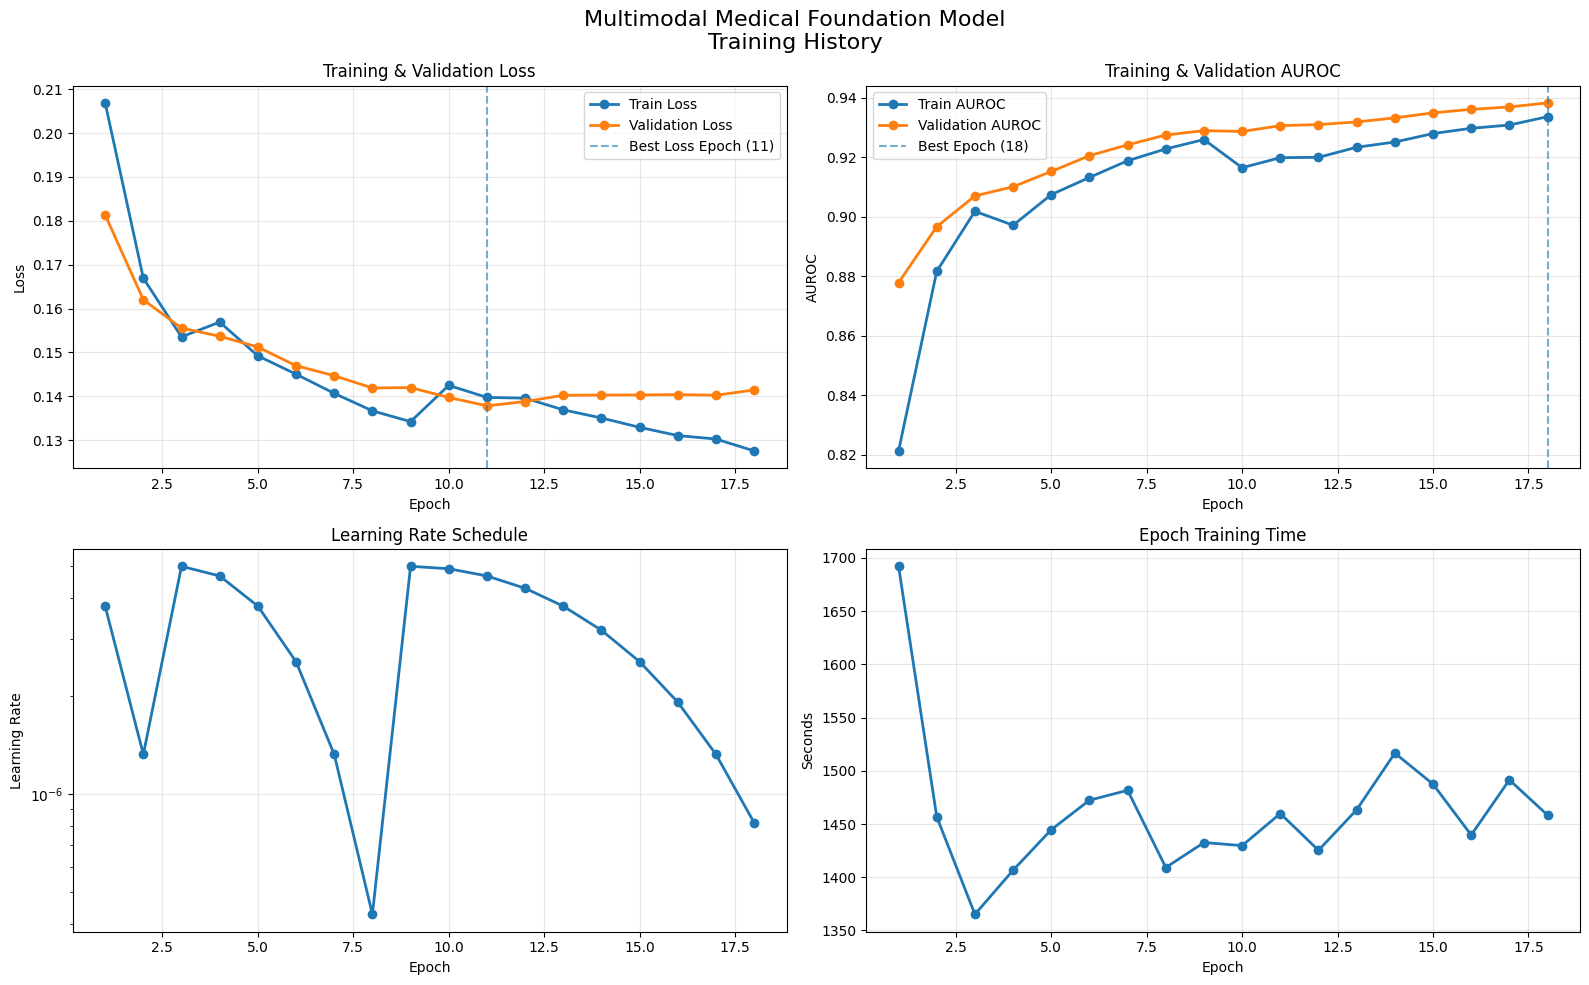


✅ Saved: /kaggle/working/artifacts/training_history.png
✅ Saved: /kaggle/working/artifacts/training_history.pdf

📈 Best Validation AUROC:
0.9383
Best Epoch: 18


In [42]:
# ============================================================
# 11.1 Training History Visualization (RESEARCH GRADE)
# ============================================================

def plot_training_history(
    history: dict,
    save_dir: str,
):
    """
    Plot training history.

    Generates:
        1. Loss curves
        2. AUROC curves
        3. Learning-rate schedule
        4. Epoch training time

    Saves:
        training_history.png
        training_history.pdf
    """

    epochs = np.arange(
        1,
        len(history["train_loss"]) + 1
    )

    best_epoch = np.argmax(
        history["val_auroc"]
    ) + 1

    min_loss_epoch = np.argmin(
        history["val_loss"]
    ) + 1

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(16, 10)
    )

    # =========================================================
    # LOSS
    # =========================================================

    axes[0, 0].plot(
        epochs,
        history["train_loss"],
        marker="o",
        linewidth=2,
        label="Train Loss"
    )

    axes[0, 0].plot(
        epochs,
        history["val_loss"],
        marker="o",
        linewidth=2,
        label="Validation Loss"
    )

    axes[0, 0].axvline(
        min_loss_epoch,
        linestyle="--",
        alpha=0.6,
        label=f"Best Loss Epoch ({min_loss_epoch})"
    )

    axes[0, 0].set_title(
        "Training & Validation Loss"
    )

    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].grid(alpha=0.3)
    axes[0, 0].legend()

    # =========================================================
    # AUROC
    # =========================================================

    axes[0, 1].plot(
        epochs,
        history["train_auroc"],
        marker="o",
        linewidth=2,
        label="Train AUROC"
    )

    axes[0, 1].plot(
        epochs,
        history["val_auroc"],
        marker="o",
        linewidth=2,
        label="Validation AUROC"
    )

    axes[0, 1].axvline(
        best_epoch,
        linestyle="--",
        alpha=0.6,
        label=f"Best Epoch ({best_epoch})"
    )

    axes[0, 1].set_title(
        "Training & Validation AUROC"
    )

    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("AUROC")
    axes[0, 1].grid(alpha=0.3)
    axes[0, 1].legend()

    # =========================================================
    # LEARNING RATE
    # =========================================================

    axes[1, 0].plot(
        epochs,
        history["lr"],
        marker="o",
        linewidth=2
    )

    axes[1, 0].set_yscale("log")

    axes[1, 0].set_title(
        "Learning Rate Schedule"
    )

    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Learning Rate")
    axes[1, 0].grid(alpha=0.3)

    # =========================================================
    # EPOCH TIME
    # =========================================================

    if "epoch_time" in history:

        axes[1, 1].plot(
            epochs,
            history["epoch_time"],
            marker="o",
            linewidth=2
        )

        axes[1, 1].set_title(
            "Epoch Training Time"
        )

        axes[1, 1].set_xlabel("Epoch")
        axes[1, 1].set_ylabel("Seconds")
        axes[1, 1].grid(alpha=0.3)

    else:

        axes[1, 1].axis("off")

    plt.suptitle(
        "Multimodal Medical Foundation Model\nTraining History",
        fontsize=16
    )

    plt.tight_layout()

    png_path = os.path.join(
        save_dir,
        "training_history.png"
    )

    pdf_path = os.path.join(
        save_dir,
        "training_history.pdf"
    )

    plt.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    plt.show()

    print(f"\n✅ Saved: {png_path}")
    print(f"✅ Saved: {pdf_path}")

    print("\n📈 Best Validation AUROC:")
    print(
        f"{max(history['val_auroc']):.4f}"
    )

    print(
        f"Best Epoch: {best_epoch}"
    )


# ============================================================
# Generate Plots
# ============================================================

plot_training_history(
    history=history,
    save_dir=CONFIG["output_dir"],
)

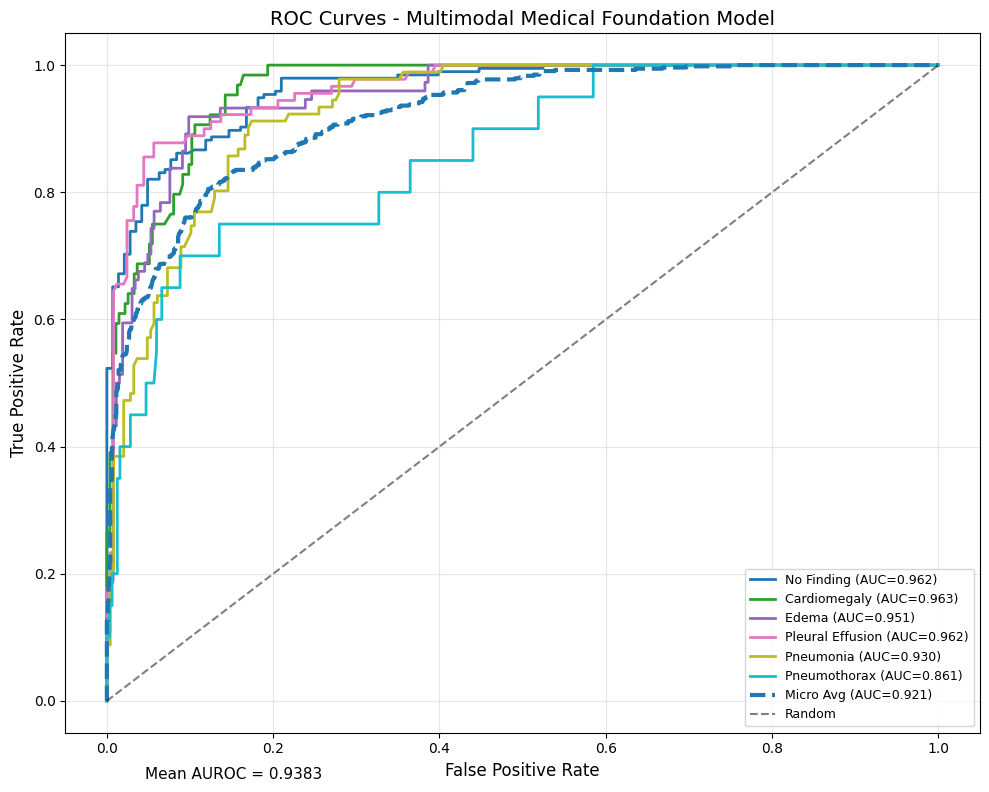

✅ Saved: /kaggle/working/artifacts/roc_curves.png
✅ Saved: /kaggle/working/artifacts/roc_curves.pdf


In [43]:
# ============================================================
# 11.2 ROC Curves (RESEARCH GRADE)
# ============================================================

def plot_roc_curves(
    labels: np.ndarray,
    probs: np.ndarray,
    disease_names: List[str],
    save_dir: str,
):
    """
    Plot per-disease, micro-average and macro-average ROC curves.
    """

    fig, ax = plt.subplots(
        figsize=(10, 8)
    )

    colors = plt.cm.tab10(
        np.linspace(0, 1, len(disease_names))
    )

    auc_scores = []

    # =========================================================
    # Individual Disease ROC Curves
    # =========================================================

    for i, (disease, color) in enumerate(
        zip(disease_names, colors)
    ):

        try:

            fpr, tpr, _ = roc_curve(
                labels[:, i],
                probs[:, i]
            )

            auc_value = roc_auc_score(
                labels[:, i],
                probs[:, i]
            )

            auc_scores.append(auc_value)

            ax.plot(
                fpr,
                tpr,
                linewidth=2,
                color=color,
                label=f"{disease} (AUC={auc_value:.3f})"
            )

        except Exception:

            print(
                f"⚠️ Could not compute ROC for {disease}"
            )

    # =========================================================
    # Micro-average ROC
    # =========================================================

    try:

        micro_fpr, micro_tpr, _ = roc_curve(
            labels.ravel(),
            probs.ravel()
        )

        micro_auc = roc_auc_score(
            labels,
            probs,
            average="micro"
        )

        ax.plot(
            micro_fpr,
            micro_tpr,
            linestyle="--",
            linewidth=3,
            label=f"Micro Avg (AUC={micro_auc:.3f})"
        )

    except Exception:
        pass

    # =========================================================
    # Random Classifier
    # =========================================================

    ax.plot(
        [0, 1],
        [0, 1],
        "k--",
        linewidth=1.5,
        alpha=0.5,
        label="Random"
    )

    # =========================================================
    # Formatting
    # =========================================================

    ax.set_xlabel(
        "False Positive Rate",
        fontsize=12
    )

    ax.set_ylabel(
        "True Positive Rate",
        fontsize=12
    )

    ax.set_title(
        "ROC Curves - Multimodal Medical Foundation Model",
        fontsize=14
    )

    ax.grid(alpha=0.3)

    ax.legend(
        loc="lower right",
        fontsize=9
    )

    mean_auc = np.mean(auc_scores)

    plt.figtext(
        0.15,
        0.02,
        f"Mean AUROC = {mean_auc:.4f}",
        fontsize=11
    )

    plt.tight_layout()

    png_path = os.path.join(
        save_dir,
        "roc_curves.png"
    )

    pdf_path = os.path.join(
        save_dir,
        "roc_curves.pdf"
    )

    plt.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    plt.show()

    print(f"✅ Saved: {png_path}")
    print(f"✅ Saved: {pdf_path}")


# ============================================================
# Generate ROC Curves
# ============================================================

# Recommended:
# Use best performing model results

plot_roc_curves(

    labels=ema_results["labels"],

    probs=ema_results["probs"],

    disease_names=CONFIG["disease_labels"],

    save_dir=CONFIG["output_dir"],

)

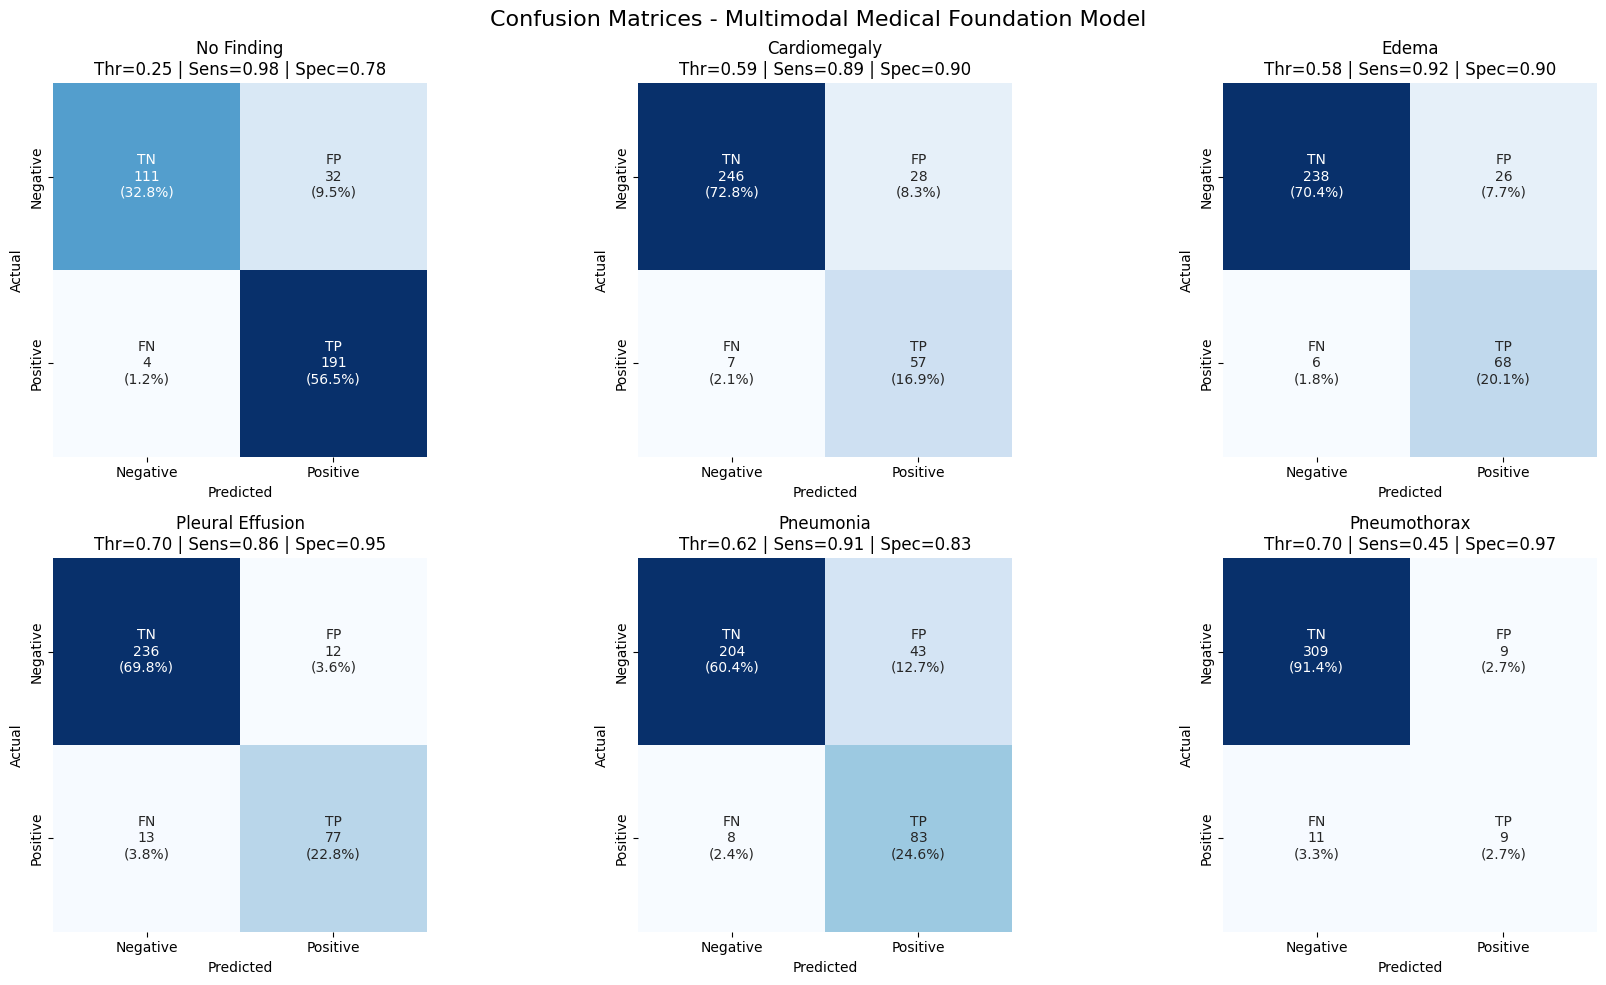

✅ Saved: /kaggle/working/artifacts/confusion_matrices.png
✅ Saved: /kaggle/working/artifacts/confusion_matrices.pdf


In [44]:
# ============================================================
# 11.3 Confusion Matrices (RESEARCH GRADE)
# ============================================================

def plot_confusion_matrices(
    labels: np.ndarray,
    probs: np.ndarray,
    thresholds: np.ndarray,
    disease_names: List[str],
    save_dir: str,
):
    """
    Plot per-disease confusion matrices.

    Shows:
        - Counts
        - Percentages
        - Sensitivity
        - Specificity
    """

    preds = (
        probs >= thresholds
    ).astype(int)

    n_classes = len(disease_names)

    n_cols = 3
    n_rows = math.ceil(
        n_classes / n_cols
    )

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(18, 10)
    )

    axes = axes.flatten()

    for i, disease in enumerate(disease_names):

        cm = confusion_matrix(
            labels[:, i],
            preds[:, i],
            labels=[0, 1]
        )

        tn, fp, fn, tp = cm.ravel()

        total = cm.sum()

        cm_percent = (
            cm / total * 100
        )

        annotations = np.array([
            [
                f"TN\n{tn}\n({cm_percent[0,0]:.1f}%)",
                f"FP\n{fp}\n({cm_percent[0,1]:.1f}%)"
            ],
            [
                f"FN\n{fn}\n({cm_percent[1,0]:.1f}%)",
                f"TP\n{tp}\n({cm_percent[1,1]:.1f}%)"
            ]
        ])

        sns.heatmap(
            cm,
            annot=annotations,
            fmt="",
            cmap="Blues",
            cbar=False,
            square=True,
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"],
            ax=axes[i],
        )

        sensitivity = (
            tp / (tp + fn + 1e-8)
        )

        specificity = (
            tn / (tn + fp + 1e-8)
        )

        axes[i].set_title(
            f"{disease}\n"
            f"Thr={thresholds[i]:.2f} | "
            f"Sens={sensitivity:.2f} | "
            f"Spec={specificity:.2f}"
        )

        axes[i].set_xlabel(
            "Predicted"
        )

        axes[i].set_ylabel(
            "Actual"
        )

    # Hide unused plots
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(
        "Confusion Matrices - Multimodal Medical Foundation Model",
        fontsize=16
    )

    plt.tight_layout()

    png_path = os.path.join(
        save_dir,
        "confusion_matrices.png"
    )

    pdf_path = os.path.join(
        save_dir,
        "confusion_matrices.pdf"
    )

    plt.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    plt.show()

    print(f"✅ Saved: {png_path}")
    print(f"✅ Saved: {pdf_path}")


# ============================================================
# Generate Confusion Matrices
# ============================================================

# Recommended:
# Use best-performing model

plot_confusion_matrices(

    labels=ema_results["labels"],

    probs=ema_results["probs"],

    thresholds=ema_thresholds,

    disease_names=CONFIG["disease_labels"],

    save_dir=CONFIG["output_dir"],
)

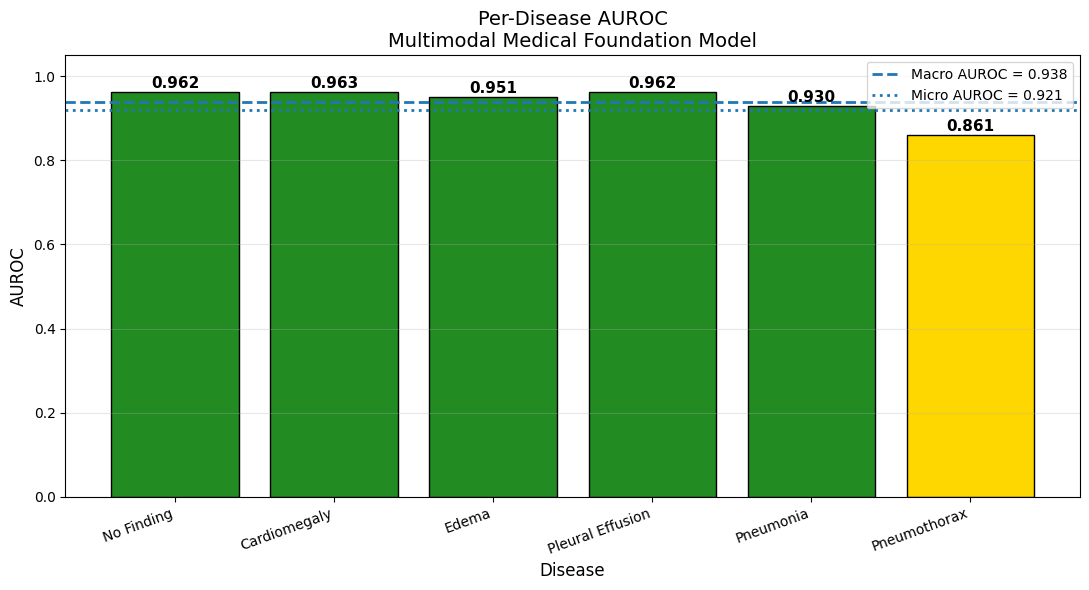

✅ Saved: /kaggle/working/artifacts/auroc_bar_chart.png
✅ Saved: /kaggle/working/artifacts/auroc_bar_chart.pdf


In [45]:
# ============================================================
# 11.4 AUROC Bar Chart (RESEARCH GRADE)
# ============================================================

def plot_auroc_bar(
    metrics: Dict[str, Any],
    disease_names: List[str],
    save_dir: str,
):
    """
    Plot per-disease AUROC bar chart.

    Includes:
        - Per-disease AUROC
        - Macro AUROC line
        - Micro AUROC line
    """

    aurocs = [

        metrics["per_disease"][disease]["auroc"]

        for disease in disease_names

    ]

    macro_auroc = metrics["aggregate"]["macro_auroc"]

    micro_auroc = metrics["aggregate"]["micro_auroc"]

    # =========================================================
    # Dynamic Colors
    # =========================================================

    colors = []

    for auc in aurocs:

        if auc >= 0.90:
            colors.append("forestgreen")

        elif auc >= 0.80:
            colors.append("gold")

        else:
            colors.append("tomato")

    # =========================================================
    # Plot
    # =========================================================

    fig, ax = plt.subplots(
        figsize=(11, 6)
    )

    bars = ax.bar(

        disease_names,

        aurocs,

        color=colors,

        edgecolor="black",

        linewidth=1.0,
    )

    # =========================================================
    # Value Labels
    # =========================================================

    for bar, value in zip(
        bars,
        aurocs
    ):

        ax.text(

            bar.get_x()
            + bar.get_width() / 2,

            value + 0.01,

            f"{value:.3f}",

            ha="center",

            fontsize=11,

            fontweight="bold",
        )

    # =========================================================
    # Reference Lines
    # =========================================================

    ax.axhline(

        macro_auroc,

        linestyle="--",

        linewidth=2,

        label=f"Macro AUROC = {macro_auroc:.3f}",
    )

    ax.axhline(

        micro_auroc,

        linestyle=":",

        linewidth=2,

        label=f"Micro AUROC = {micro_auroc:.3f}",
    )

    # =========================================================
    # Formatting
    # =========================================================

    ax.set_ylim(0, 1.05)

    ax.set_ylabel(
        "AUROC",
        fontsize=12
    )

    ax.set_xlabel(
        "Disease",
        fontsize=12
    )

    ax.set_title(
        "Per-Disease AUROC\nMultimodal Medical Foundation Model",
        fontsize=14
    )

    ax.grid(
        alpha=0.3,
        axis="y"
    )

    plt.xticks(
        rotation=20,
        ha="right"
    )

    ax.legend()

    plt.tight_layout()

    # =========================================================
    # Save
    # =========================================================

    png_path = os.path.join(
        save_dir,
        "auroc_bar_chart.png"
    )

    pdf_path = os.path.join(
        save_dir,
        "auroc_bar_chart.pdf"
    )

    plt.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    plt.show()

    print(f"✅ Saved: {png_path}")
    print(f"✅ Saved: {pdf_path}")


# ============================================================
# Generate AUROC Bar Chart
# ============================================================

# Use best-performing model metrics

plot_auroc_bar(

    metrics=ema_metrics,

    disease_names=CONFIG["disease_labels"],

    save_dir=CONFIG["output_dir"],
)

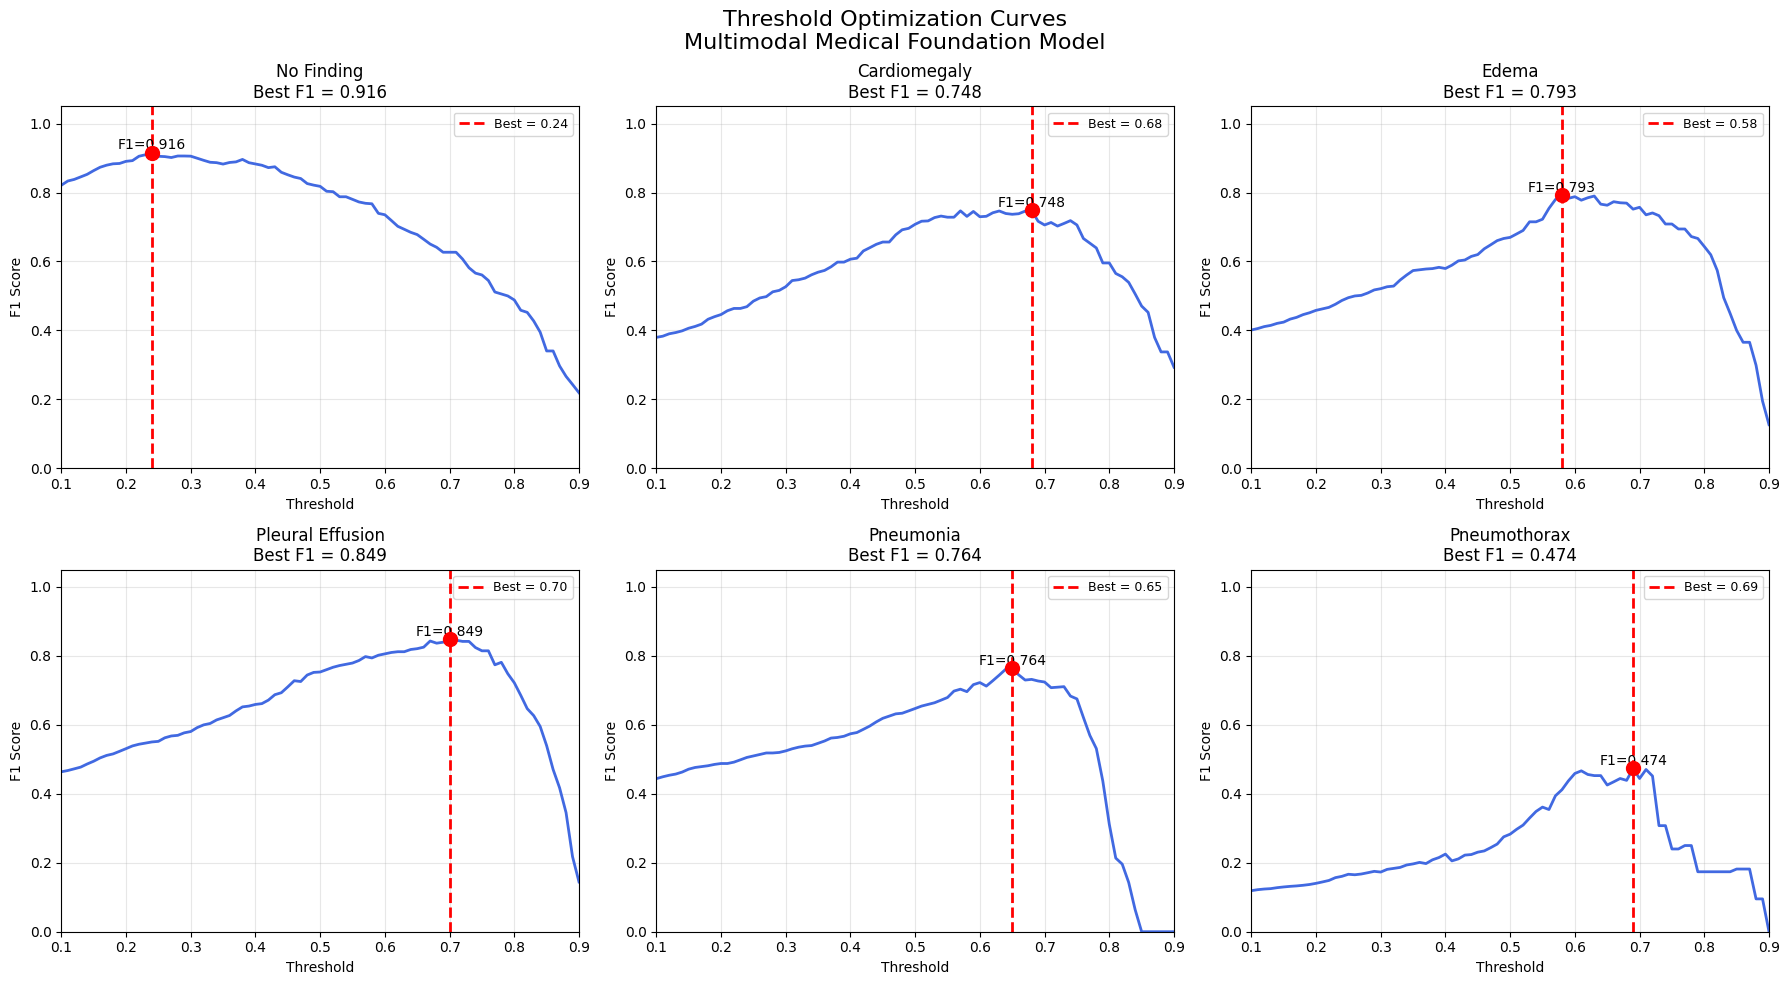

✅ Saved: /kaggle/working/artifacts/threshold_optimization_curves.png
✅ Saved: /kaggle/working/artifacts/threshold_optimization_curves.pdf


In [46]:
# ============================================================
# 11.5 Threshold Optimization Curves (RESEARCH GRADE)
# ============================================================

def plot_threshold_curves(
    threshold_info: Dict[str, Any],
    disease_names: List[str],
    save_dir: str,
):
    """
    Plot threshold vs F1 curves for every disease.

    Parameters
    ----------
    threshold_info : dict
        Output from optimize_thresholds()
    disease_names : list
        List of disease labels
    save_dir : str
        Directory where figures will be saved
    """

    n_classes = len(disease_names)

    n_cols = 3
    n_rows = math.ceil(n_classes / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(18, 10)
    )

    axes = axes.flatten()

    for i, disease in enumerate(disease_names):

        curve = threshold_info[disease]["curve"]

        thresholds = [
            point["threshold"]
            for point in curve
        ]

        f1_scores = [
            point["f1"]
            for point in curve
        ]

        best_threshold = threshold_info[disease][
            "best_threshold"
        ]

        best_f1 = threshold_info[disease][
            "best_f1"
        ]

        # =====================================================
        # Plot curve
        # =====================================================

        axes[i].plot(
            thresholds,
            f1_scores,
            linewidth=2,
            color="royalblue"
        )

        # Best threshold line
        axes[i].axvline(
            x=best_threshold,
            color="red",
            linestyle="--",
            linewidth=2,
            label=f"Best = {best_threshold:.2f}"
        )

        # Best point
        axes[i].scatter(
            best_threshold,
            best_f1,
            color="red",
            s=100,
            zorder=5
        )

        axes[i].text(
            best_threshold,
            best_f1 + 0.01,
            f"F1={best_f1:.3f}",
            fontsize=10,
            ha="center"
        )

        # Formatting
        axes[i].set_title(
            f"{disease}\nBest F1 = {best_f1:.3f}",
            fontsize=12
        )

        axes[i].set_xlabel(
            "Threshold"
        )

        axes[i].set_ylabel(
            "F1 Score"
        )

        axes[i].set_xlim(
            CONFIG["threshold_start"],
            CONFIG["threshold_end"]
        )

        axes[i].set_ylim(0, 1.05)

        axes[i].grid(
            alpha=0.3
        )

        axes[i].legend(
            fontsize=9
        )

    # =========================================================
    # Hide unused axes
    # =========================================================

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(
        "Threshold Optimization Curves\nMultimodal Medical Foundation Model",
        fontsize=16
    )

    plt.tight_layout()

    # =========================================================
    # Save
    # =========================================================

    png_path = os.path.join(
        save_dir,
        "threshold_optimization_curves.png"
    )

    pdf_path = os.path.join(
        save_dir,
        "threshold_optimization_curves.pdf"
    )

    plt.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.savefig(
        pdf_path,
        bbox_inches="tight"
    )

    plt.show()

    print(f"✅ Saved: {png_path}")
    print(f"✅ Saved: {pdf_path}")


# ============================================================
# Generate Threshold Optimization Curves
# ============================================================

# Use the threshold_info obtained from:
# optimal_thresholds, threshold_info = optimize_thresholds(...)

plot_threshold_curves(

    threshold_info=threshold_info,

    disease_names=CONFIG["disease_labels"],

    save_dir=CONFIG["output_dir"],

)

In [48]:
# ============================================================
# CREATE ZIP WITHOUT MODEL FILES
# ============================================================

import os
import zipfile

artifact_dir = "/kaggle/working/artifacts"
zip_path = "/kaggle/working/artifacts_no_models.zip"

exclude_files = {
    "best_model.pth",
    "best_model_ema.pth",
    "checkpoint_last.pth"
}

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:

    for root, dirs, files in os.walk(artifact_dir):

        for file in files:

            if file in exclude_files:
                continue

            filepath = os.path.join(root, file)

            arcname = os.path.relpath(
                filepath,
                artifact_dir
            )

            zipf.write(filepath, arcname)

print("✅ ZIP created:")
print(zip_path)

✅ ZIP created:
/kaggle/working/artifacts_no_models.zip


In [51]:
!pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 55.7 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [52]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [55]:
# ============================================================
# 12.1 GradCAM for BiomedCLIP ViT (FIXED VERSION)
# ============================================================

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

class BiomedCLIPGradCAM:

    def __init__(
        self,
        model: nn.Module,
        target_block_idx: int = -2,
    ):

        self.model = model

        self.base_model = (
            model.module
            if hasattr(model, "module")
            else model
        )

        # ------------------------------------------------------
        # Try to locate image encoder automatically
        # ------------------------------------------------------

        possible_names = [

            "image_encoder",
            "image_model",
            "vision_encoder",
            "image_backbone",
            "image_branch",
            "biomedclip",
            "visual",
        ]

        image_encoder = None

        for name in possible_names:

            if hasattr(self.base_model, name):

                image_encoder = getattr(
                    self.base_model,
                    name
                )

                print(
                    f"✅ Found image encoder: {name}"
                )

                break

        if image_encoder is None:

            print("\nAvailable model attributes:\n")

            for name in dir(self.base_model):

                if not name.startswith("_"):

                    print(name)

            raise ValueError(
                "Could not locate image encoder."
            )

        # ------------------------------------------------------
        # Locate ViT blocks
        # ------------------------------------------------------

        if hasattr(image_encoder, "transformer"):

            self.target_layer = (

                image_encoder.transformer.resblocks[
                    target_block_idx
                ]

            )

        elif hasattr(image_encoder, "trunk"):

            self.target_layer = (

                image_encoder.trunk.blocks[
                    target_block_idx
                ]

            )

        elif hasattr(image_encoder, "visual"):

            visual = image_encoder.visual

            if hasattr(visual, "transformer"):

                self.target_layer = (

                    visual.transformer.resblocks[
                        target_block_idx
                    ]

                )

            elif hasattr(visual, "trunk"):

                self.target_layer = (

                    visual.trunk.blocks[
                        target_block_idx
                    ]

                )

            else:

                raise ValueError(
                    "Could not locate transformer blocks."
                )

        else:

            raise ValueError(
                "Could not locate ViT blocks."
            )

        print(
            f"✅ Using GradCAM block {target_block_idx}"
        )

    # ----------------------------------------------------------
    # Reshape ViT tokens
    # ----------------------------------------------------------

    def reshape_transform(
        self,
        tensor
    ):

        if tensor.dim() == 3:

            # [tokens,B,C] -> [B,tokens,C]

            if tensor.shape[1] == 1:

                tensor = tensor.permute(
                    1,
                    0,
                    2
                )

        tensor = tensor[:, 1:, :]

        h = w = int(
            np.sqrt(
                tensor.shape[1]
            )
        )

        tensor = tensor.reshape(
            tensor.size(0),
            h,
            w,
            tensor.size(2),
        )

        tensor = tensor.permute(
            0,
            3,
            1,
            2,
        )

        return tensor

    # ----------------------------------------------------------
    # Generate heatmap
    # ----------------------------------------------------------

    def generate(
        self,
        image,
        input_ids,
        attention_mask,
        target_class,
    ):

        self.model.eval()

        class Wrapper(nn.Module):

            def __init__(
                self,
                multimodal_model,
                input_ids,
                attention_mask,
            ):

                super().__init__()

                self.model = multimodal_model

                self.input_ids = input_ids

                self.attention_mask = attention_mask

            def forward(
                self,
                image_tensor
            ):

                outputs = self.model(

                    image_tensor,

                    self.input_ids,

                    self.attention_mask,
                )

                if isinstance(outputs, dict):

                    return outputs["logits"]

                return outputs

        wrapper = Wrapper(

            self.model,

            input_ids,

            attention_mask,
        )

        cam = GradCAM(

            model=wrapper,

            target_layers=[
                self.target_layer
            ],

            reshape_transform=self.reshape_transform,
        )

        grayscale_cam = cam(
            input_tensor=image
        )

        heatmap = grayscale_cam[0]

        heatmap = (
            heatmap - heatmap.min()
        ) / (
            heatmap.max()
            - heatmap.min()
            + 1e-8
        )

        return heatmap


print(
    "✅ BiomedCLIPGradCAM ready."
)

✅ BiomedCLIPGradCAM ready.


✅ Found image encoder: biomedclip
✅ Using GradCAM block -2

🔍 Processing sample 1/3


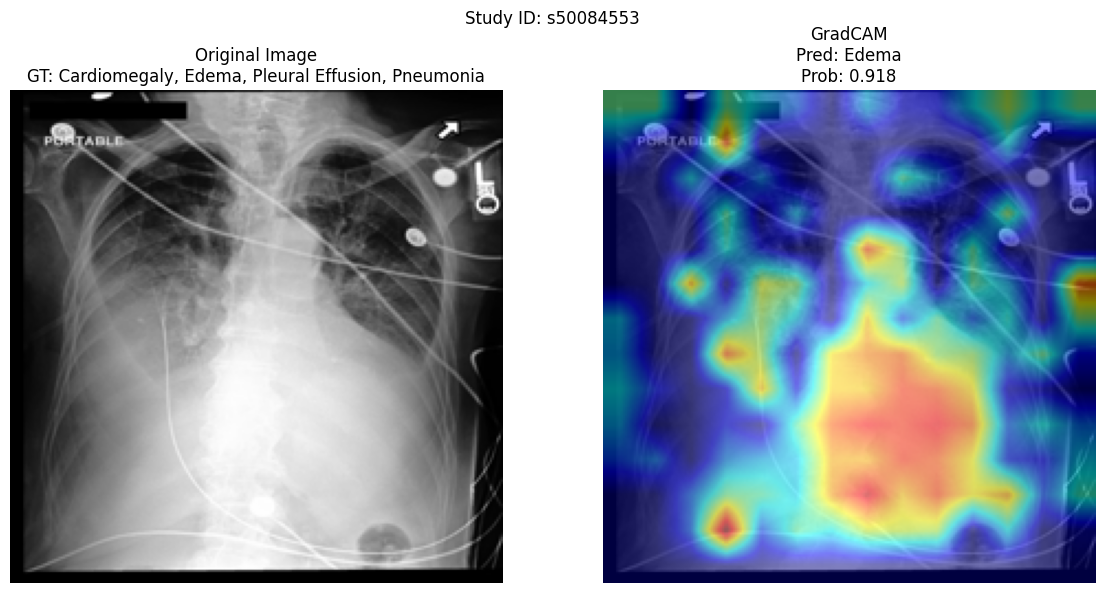

✅ Saved: /kaggle/working/artifacts/gradcam_examples/gradcam_sample_1.png

🔍 Processing sample 2/3


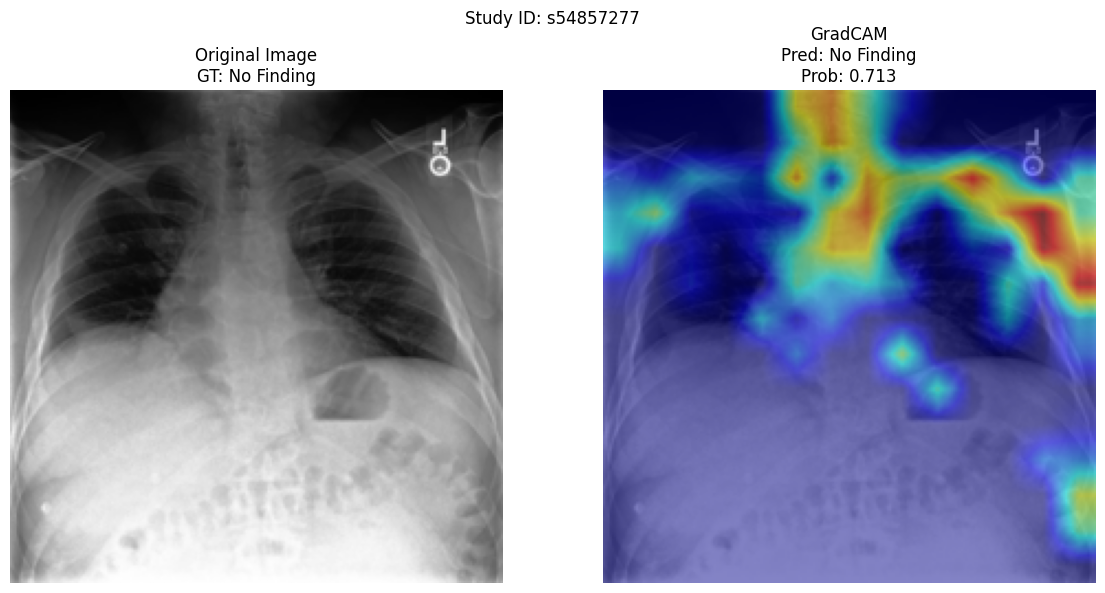

✅ Saved: /kaggle/working/artifacts/gradcam_examples/gradcam_sample_2.png

🔍 Processing sample 3/3


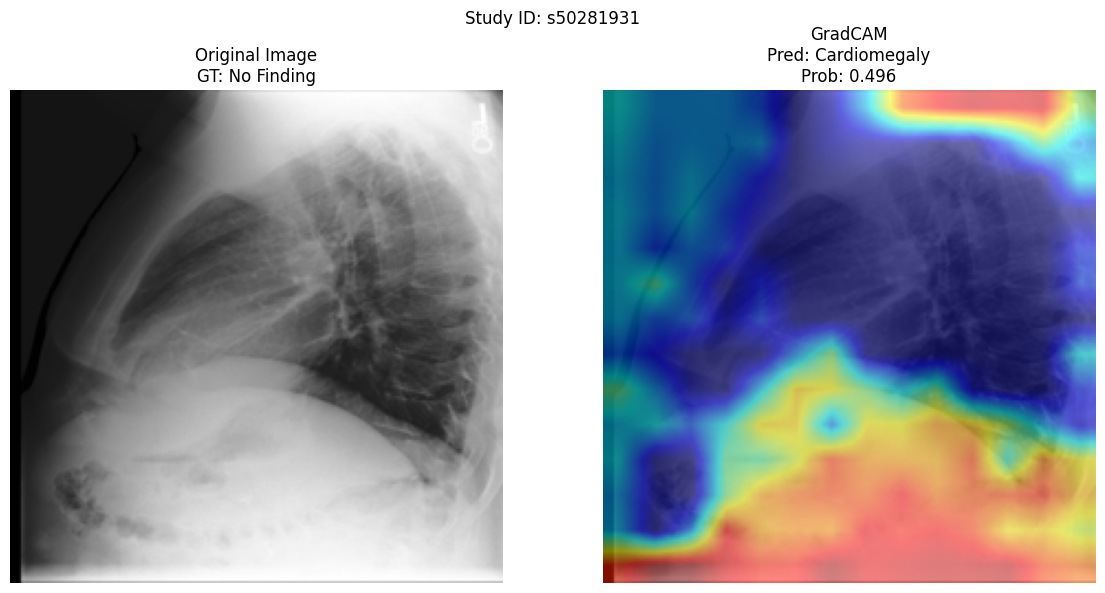

✅ Saved: /kaggle/working/artifacts/gradcam_examples/gradcam_sample_3.png


In [57]:
# ============================================================
# 12.2 GradCAM Visualization Examples (FIXED)
# ============================================================

from pytorch_grad_cam.utils.image import show_cam_on_image

def visualize_gradcam_examples(
    model: nn.Module,
    dataset: MultimodalDataset,
    device: torch.device,
    disease_names: List[str],
    n_examples: int = 3,
    save_dir: str = ".",
):

    model.eval()

    gradcam_dir = os.path.join(
        save_dir,
        "gradcam_examples"
    )

    os.makedirs(
        gradcam_dir,
        exist_ok=True
    )

    gradcam = BiomedCLIPGradCAM(
        model=model,
        target_block_idx=CONFIG["gradcam_block_idx"],
    )

    for sample_idx in range(
        min(n_examples, len(dataset))
    ):

        print(
            f"\n🔍 Processing sample "
            f"{sample_idx + 1}/{n_examples}"
        )

        sample = dataset[sample_idx]

        image = sample["image"].unsqueeze(0).to(device)

        input_ids = sample[
            "input_ids"
        ].unsqueeze(0).to(device)

        attention_mask = sample[
            "attention_mask"
        ].unsqueeze(0).to(device)

        labels = sample[
            "labels"
        ].cpu().numpy()

        # =====================================================
        # Prediction
        # =====================================================

        with torch.no_grad():

            outputs = model(
                image,
                input_ids,
                attention_mask,
            )

            # ------------------------------------------
            # Handle tensor and dict outputs
            # ------------------------------------------

            if isinstance(outputs, dict):
                logits = outputs["logits"]
            else:
                logits = outputs

            probs = torch.sigmoid(
                logits
            ).cpu().numpy()[0]

        predicted_class = int(
            np.argmax(probs)
        )

        # =====================================================
        # Ground Truth Labels
        # =====================================================

        gt_labels = [

            disease_names[i]

            for i in range(len(labels))

            if labels[i] > 0.5

        ]

        if len(gt_labels) == 0:
            gt_labels = ["No Positive Label"]

        # =====================================================
        # Original Image
        # =====================================================

        image_path = dataset.df.iloc[
            sample_idx
        ]["image_path"]

        original_image = Image.open(
            image_path
        ).convert("RGB")

        original_image = original_image.resize(
            (
                CONFIG["image_size"],
                CONFIG["image_size"]
            )
        )

        original_np = (
            np.array(original_image)
            .astype(np.float32)
            / 255.0
        )

        # =====================================================
        # GradCAM
        # =====================================================

        try:

            heatmap = gradcam.generate(
                image=image,
                input_ids=input_ids,
                attention_mask=attention_mask,
                target_class=predicted_class,
            )

            overlay = show_cam_on_image(
                original_np,
                heatmap,
                use_rgb=True,
            )

        except Exception as e:

            print(
                f"❌ GradCAM failed: {e}"
            )

            continue

        # =====================================================
        # Visualization
        # =====================================================

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(12, 6)
        )

        axes[0].imshow(original_np)

        axes[0].set_title(
            "Original Image\n"
            f"GT: {', '.join(gt_labels)}"
        )

        axes[0].axis("off")

        axes[1].imshow(overlay)

        axes[1].set_title(
            "GradCAM\n"
            f"Pred: "
            f"{disease_names[predicted_class]}\n"
            f"Prob: "
            f"{probs[predicted_class]:.3f}"
        )

        axes[1].axis("off")

        plt.suptitle(
            f"Study ID: "
            f"{sample['study_id']}"
        )

        plt.tight_layout()

        save_path = os.path.join(
            gradcam_dir,
            f"gradcam_sample_{sample_idx + 1}.png"
        )

        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        print(
            f"✅ Saved: {save_path}"
        )


# ============================================================
# Generate GradCAM Examples
# ============================================================

visualize_gradcam_examples(
    model=model,
    dataset=val_dataset,
    device=DEVICE,
    disease_names=CONFIG["disease_labels"],
    n_examples=3,
    save_dir=CONFIG["output_dir"],
)

In [64]:
import torch

try:
    x = torch.randn(2, 2).cuda()
    print("✅ CUDA still works")
except Exception as e:
    print("❌ CUDA broken")
    print(e)

❌ CUDA broken
CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.



In [62]:
# ============================================================
# 12.3 Text Attribution (FIXED FOR YOUR ARCHITECTURE)
# ============================================================

from captum.attr import IntegratedGradients


class TextAttributor:

    def __init__(
        self,
        model,
        tokenizer,
        device
    ):

        self.model = model
        self.tokenizer = tokenizer
        self.device = device

        self.base_model = (
            model.module
            if hasattr(model, "module")
            else model
        )

    # ----------------------------------------------------------
    # Forward for Integrated Gradients
    # ----------------------------------------------------------

    def _forward_text_only(
        self,
        input_embeds,
        attention_mask,
        image_embed
    ):

        text_outputs = self.base_model.text_encoder(

            inputs_embeds=input_embeds,

            attention_mask=attention_mask,

        )

        text_cls = (
            text_outputs
            .last_hidden_state[:, 0, :]
        )

        # Projection layer

        text_embed = (
            self.base_model.text_projection(
                text_cls
            )
        )

        fused = torch.cat(
            [
                image_embed,
                text_embed
            ],
            dim=1
        )

        logits = self.base_model.classifier(
            fused
        )

        return logits

    # ----------------------------------------------------------
    # Attribution
    # ----------------------------------------------------------

    def attribute(
        self,
        text,
        image,
        target_class,
        n_steps=50
    ):

        self.model.eval()

        encoding = self.tokenizer(

            text,

            max_length=CONFIG[
                "max_text_len"
            ],

            padding="max_length",

            truncation=True,

            return_tensors="pt",

        )

        input_ids = encoding[
            "input_ids"
        ].to(self.device)

        attention_mask = encoding[
            "attention_mask"
        ].to(self.device)

        # ------------------------------------------------------
        # Token embeddings
        # ------------------------------------------------------

        token_embeddings = (

            self.base_model
            .text_encoder
            .embeddings(
                input_ids=input_ids
            )

        )

        token_embeddings = (
            token_embeddings
            .detach()
            .requires_grad_(True)
        )

        # ------------------------------------------------------
        # Fixed image embedding
        # ------------------------------------------------------

        with torch.no_grad():

            image_embed = (

                self.base_model
                .get_image_embedding(
                    image
                )

            )

        image_embed = image_embed.detach()

        baseline = torch.zeros_like(
            token_embeddings
        )

        ig = IntegratedGradients(

            lambda embeds:

            self._forward_text_only(

                embeds,

                attention_mask,

                image_embed,

            )

        )

        attributions = ig.attribute(

            token_embeddings,

            baselines=baseline,

            target=target_class,

            n_steps=n_steps,

        )

        # ------------------------------------------------------
        # Token scores
        # ------------------------------------------------------

        scores = (

            attributions

            .sum(dim=-1)

            .squeeze(0)

            .cpu()

            .detach()

            .numpy()

        )

        tokens = (

            self.tokenizer

            .convert_ids_to_tokens(

                input_ids[0]

                .cpu()

                .tolist()

            )

        )

        results = []

        for token, score, mask in zip(

            tokens,

            scores,

            attention_mask[0]
            .cpu()
            .tolist()

        ):

            if (

                mask == 1

                and token not in

                ["[CLS]", "[SEP]", "[PAD]"]

            ):

                results.append(

                    (
                        token,
                        float(score)
                    )

                )

        return results


# ============================================================
# Visualization Function
# ============================================================

def visualize_text_attribution(
    attributions,
    disease_name,
    top_k=20,
):

    attrs = sorted(

        attributions,

        key=lambda x: abs(x[1]),

        reverse=True

    )[:top_k]

    attrs = attrs[::-1]

    words = [x[0] for x in attrs]
    scores = [x[1] for x in attrs]

    colors = [

        "green"
        if s > 0
        else "red"

        for s in scores

    ]

    plt.figure(
        figsize=(10, 6)
    )

    plt.barh(
        range(len(words)),
        scores,
        color=colors,
        alpha=0.7
    )

    plt.yticks(
        range(len(words)),
        words
    )

    plt.xlabel(
        "Importance Score"
    )

    plt.title(
        f"Integrated Gradients\n"
        f"{disease_name}"
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


print(
    "✅ TextAttributor ready."
)

✅ TextAttributor ready.


In [63]:
# ============================================================
# 12.4 Text Attribution Examples (FIXED)
# ============================================================

# Initialize explainer
text_attributor = TextAttributor(
    model=model,
    tokenizer=tokenizer,
    device=DEVICE,
)

# Directory for saving plots
text_attr_dir = os.path.join(
    CONFIG["output_dir"],
    "text_attributions"
)

os.makedirs(
    text_attr_dir,
    exist_ok=True
)

# ============================================================
# Generate Examples
# ============================================================

num_examples = min(5, len(val_dataset))

for sample_idx in range(num_examples):

    print("\n" + "=" * 80)

    sample = val_dataset[sample_idx]

    image = sample["image"].unsqueeze(0).to(DEVICE)

    labels = sample["labels"].cpu().numpy()

    # --------------------------------------------------------
    # Report text
    # --------------------------------------------------------

    if "report" in df_val.columns:
        report = df_val.iloc[sample_idx]["report"]
    elif "text" in df_val.columns:
        report = df_val.iloc[sample_idx]["text"]
    else:
        raise ValueError(
            "Could not find report/text column."
        )

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    with torch.no_grad():

        input_ids = sample[
            "input_ids"
        ].unsqueeze(0).to(DEVICE)

        attention_mask = sample[
            "attention_mask"
        ].unsqueeze(0).to(DEVICE)

        outputs = model(
            image,
            input_ids,
            attention_mask,
        )

        # ====================================================
        # Handle both tensor and dict outputs
        # ====================================================

        if isinstance(outputs, dict):

            logits = outputs["logits"]

        else:

            logits = outputs

        probabilities = torch.sigmoid(
            logits
        ).cpu().numpy()[0]

    # --------------------------------------------------------
    # Ground Truth Labels
    # --------------------------------------------------------

    gt_labels = [

        CONFIG["disease_labels"][i]

        for i in range(len(labels))

        if labels[i] > 0.5

    ]

    if len(gt_labels) == 0:

        gt_labels = ["No Positive Label"]

    # --------------------------------------------------------
    # Select Target Disease
    # --------------------------------------------------------

    positive_classes = np.where(
        labels > 0.5
    )[0]

    if len(positive_classes) > 0:

        probs_positive = probabilities[
            positive_classes
        ]

        target_class = positive_classes[
            np.argmax(probs_positive)
        ]

    else:

        target_class = np.argmax(
            probabilities
        )

    disease_name = CONFIG[
        "disease_labels"
    ][target_class]

    print(
        f"📝 Sample {sample_idx + 1}"
    )

    print(
        f"Study ID : {sample['study_id']}"
    )

    print(
        f"GT Labels: {', '.join(gt_labels)}"
    )

    print(
        f"Target Disease : {disease_name}"
    )

    print(
        f"Predicted Probability : "
        f"{probabilities[target_class]:.3f}"
    )

    print("\nReport Snippet:\n")

    print(
        str(report)[:350] + "..."
    )

    print("\n" + "=" * 80)

    # --------------------------------------------------------
    # Attribution
    # --------------------------------------------------------

    try:

        attributions = text_attributor.attribute(

            text=str(report),

            image=image,

            target_class=int(
                target_class
            ),

            n_steps=50,

        )

        # ----------------------------------------------------
        # Visualization
        # ----------------------------------------------------

        if len(attributions) > 0:

            visualize_text_attribution(
                attributions=attributions,
                disease_name=disease_name,
                top_k=20,
            )

        else:

            print(
                "⚠️ No attributions generated."
            )

    except Exception as e:

        print(
            f"❌ Attribution failed: {e}"
        )


📝 Sample 1
Study ID : s50084553
GT Labels: Cardiomegaly, Edema, Pleural Effusion, Pneumonia
Target Disease : Edema
Predicted Probability : 0.918

Report Snippet:

findings: impression: compared to chest radiographs since ___, most recently ___. large right and moderate left pleural effusions and severe bibasilar atelectasis are unchanged. cardiac silhouette is obscured. no pneumothorax. pulmonary edema is mild, obscured radiographically by overlying abnormalities. findings: no evidence of consolidation to su...

❌ Attribution failed: Sizes of tensors must match except in dimension 1. Expected size 1 but got size 50 for tensor number 1 in the list.

📝 Sample 2
Study ID : s54857277
GT Labels: No Finding
Target Disease : No Finding
Predicted Probability : 0.713

Report Snippet:

findings: impression: findings: low lung volumes, no pleural effusions. no parenchymal abnormality, in particular no evidence of pneumonia. borderline size of the cardiac silhouette without pulmonary edema. no hi

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [65]:
# ============================================================
# 13.1 Predict Single Sample
# ============================================================

def predict_single_sample(
    model: nn.Module,
    image_path: str,
    report_text: str,
    tokenizer,
    transforms: T.Compose,
    thresholds: np.ndarray,
    disease_names: List[str],
    device: torch.device,
    generate_gradcam: bool = True,
    generate_text_attr: bool = True,
) -> Dict[str, Any]:
    """Complete inference pipeline for a single sample.
    
    Args:
        model: trained ImageTextClassifier
        image_path: path to chest X-ray image
        report_text: radiology report text
        tokenizer: BioClinicalBERT tokenizer
        transforms: image preprocessing transforms
        thresholds: per-class thresholds
        disease_names: list of disease names
        device: compute device
        generate_gradcam: whether to generate GradCAM
        generate_text_attr: whether to generate text attribution
    
    Returns:
        dict with probabilities, predictions, GradCAM, text attribution
    """
    model.eval()

    # ── Preprocess image ───────────────────────────────────────
    image = Image.open(image_path).convert("RGB")
    image_tensor = transforms(image).unsqueeze(0).to(device)

    # ── Preprocess text ────────────────────────────────────────
    cleaned_text = clean_report(report_text)
    encoding = tokenizer(
        cleaned_text,
        padding="max_length",
        truncation=True,
        max_length=CONFIG["max_text_len"],
        return_tensors="pt",
    )
    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    # ── Forward pass ───────────────────────────────────────────
    with torch.no_grad():
        outputs = model(image_tensor, input_ids, attention_mask)
        probs = torch.sigmoid(outputs["logits"]).cpu().numpy()[0]

    # ── Thresholded predictions ────────────────────────────────
    preds = (probs >= thresholds).astype(int)

    # ── "No Finding" conflict suppression ─────────────────────
    # If any disease is predicted positive, suppress "No Finding"
    no_finding_idx = disease_names.index("No Finding") if "No Finding" in disease_names else 0
    if preds.sum() > 1 and preds[no_finding_idx] == 1:
        # Check if any disease other than "No Finding" is positive
        other_positive = preds.copy()
        other_positive[no_finding_idx] = 0
        if other_positive.sum() > 0:
            preds[no_finding_idx] = 0
            print("   ⚡ 'No Finding' suppressed (conflict with positive disease predictions)")

    result = {
        "probabilities": {name: float(p) for name, p in zip(disease_names, probs)},
        "predictions": {name: int(p) for name, p in zip(disease_names, preds)},
        "thresholds": {name: float(t) for name, t in zip(disease_names, thresholds)},
    }

    # ── GradCAM ────────────────────────────────────────────────
    if generate_gradcam:
        try:
            target_class = int(np.argmax(probs))
            gradcam = ViTGradCAM(model, target_block_idx=-1)
            heatmap = gradcam.generate(image_tensor, input_ids, attention_mask, target_class)
            result["gradcam"] = heatmap
            result["gradcam_target"] = disease_names[target_class]
        except Exception as e:
            result["gradcam"] = None
            result["gradcam_error"] = str(e)

    # ── Text Attribution ───────────────────────────────────────
    if generate_text_attr:
        try:
            target_class = int(np.argmax(probs))
            attr = TextAttributor(model, tokenizer, device)
            attributions = attr.attribute(
                text=cleaned_text,
                image=image_tensor,
                target_class=target_class,
                n_steps=30,
            )
            # Top 10 important words
            sorted_attrs = sorted(attributions, key=lambda x: abs(x[1]), reverse=True)[:10]
            result["important_words"] = sorted_attrs
            result["text_attr_target"] = disease_names[target_class]
        except Exception as e:
            result["important_words"] = None
            result["text_attr_error"] = str(e)

    return result


print("✅ predict_single_sample function defined.")

✅ predict_single_sample function defined.


In [66]:
# ============================================================
# 13.2 Single Sample Inference Demo (RESEARCH GRADE)
# ============================================================

# ------------------------------------------------------------
# Select Demo Sample
# ------------------------------------------------------------

demo_idx = 0

demo_row = df_val.iloc[demo_idx]

demo_image_path = demo_row["image_path"]

# IMPORTANT: use report column
demo_text = demo_row["report"]

print("\n" + "="*80)
print(f"🔍 Demo Inference on Validation Sample {demo_idx}")
print("="*80)

print(f"\n🖼️ Image Path:")
print(demo_image_path)

print(f"\n📝 Report Snippet:")
print(demo_text[:300] + "...")

# ------------------------------------------------------------
# Run Inference
# ------------------------------------------------------------

demo_result = predict_single_sample(

    model=model,

    image_path=demo_image_path,

    report_text=demo_text,

    tokenizer=tokenizer,

    transforms=val_transforms,

    thresholds=ema_thresholds,

    disease_names=CONFIG["disease_labels"],

    device=DEVICE,

    generate_gradcam=True,

    generate_text_attr=True,

)

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

print("\n" + "="*80)
print("📊 PREDICTIONS")
print("="*80)

for disease in CONFIG["disease_labels"]:

    prob = demo_result["probabilities"][disease]

    pred = demo_result["predictions"][disease]

    threshold = demo_result["thresholds"][disease]

    status = "✅ Positive" if pred == 1 else "❌ Negative"

    print(
        f"{status:<15}"
        f"{disease:<22}"
        f"Prob={prob:.4f} "
        f"(Threshold={threshold:.2f})"
    )

# ------------------------------------------------------------
# Important Words
# ------------------------------------------------------------

if demo_result.get("important_words"):

    print("\n" + "="*80)
    print(
        f"📝 TOP IMPORTANT WORDS "
        f"({demo_result['text_attr_target']})"
    )
    print("="*80)

    for token, score in demo_result["important_words"]:

        print(
            f"{token:<20} "
            f"{score:+.4f}"
        )

# ------------------------------------------------------------
# GradCAM Visualization
# ------------------------------------------------------------

if demo_result.get("gradcam") is not None:

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 6)
    )

    original_image = Image.open(
        demo_image_path
    ).convert("RGB")

    original_image = original_image.resize(
        (
            CONFIG["image_size"],
            CONFIG["image_size"]
        )
    )

    original_np = np.array(
        original_image
    ).astype(np.float32) / 255.0

    axes[0].imshow(
        original_np
    )

    axes[0].set_title(
        "Original Chest X-ray"
    )

    axes[0].axis("off")

    overlay = show_cam_on_image(

        original_np,

        demo_result["gradcam"],

        use_rgb=True,

    )

    axes[1].imshow(
        overlay
    )

    axes[1].set_title(

        f"GradCAM\n"
        f"{demo_result['gradcam_target']}"

    )

    axes[1].axis("off")

    plt.tight_layout()

    plt.show()

# ------------------------------------------------------------
# Save inference result
# ------------------------------------------------------------

with open(

    os.path.join(
        CONFIG["output_dir"],
        "demo_inference_result.json"
    ),

    "w"

) as f:

    json.dump(

        {
            "probabilities":
            demo_result["probabilities"],

            "predictions":
            demo_result["predictions"],

            "thresholds":
            demo_result["thresholds"],
        },

        f,

        indent=4
    )

print(
    "\n✅ Demo inference completed."
)


🔍 Demo Inference on Validation Sample 0

🖼️ Image Path:
/kaggle/input/datasets/simhadrisadaram/mimic-cxr-dataset/official_data_iccv_final/files/p10/p10003502/s50084553/70d7e600-373c1311-929f5ff9-23ee3621-ff551ff9.jpg

📝 Report Snippet:
findings: impression: compared to chest radiographs since ___, most recently ___. large right and moderate left pleural effusions and severe bibasilar atelectasis are unchanged. cardiac silhouette is obscured. no pneumothorax. pulmonary edema is mild, obscured radiographically by overlying abnormali...


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
# ============================================================
# 14.1 Extract Embeddings (RESEARCH GRADE)
# ============================================================

@torch.no_grad()
def extract_embeddings(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
):
    """
    Extract image, text and fused embeddings.
    """

    model.eval()

    image_embeddings = []
    text_embeddings = []
    fused_embeddings = []

    study_ids = []
    labels_all = []

    for batch in tqdm(
        loader,
        desc="Extracting Embeddings"
    ):

        images = batch["image"].to(
            device,
            non_blocking=True
        )

        input_ids = batch["input_ids"].to(
            device,
            non_blocking=True
        )

        attention_mask = batch[
            "attention_mask"
        ].to(
            device,
            non_blocking=True
        )

        with autocast(
            enabled=CONFIG["mixed_precision"]
        ):

            outputs = model(

                images,

                input_ids,

                attention_mask,

            )

        image_embeddings.append(

            outputs["image_embed"]
            .float()
            .cpu()
            .numpy()

        )

        text_embeddings.append(

            outputs["text_embed"]
            .float()
            .cpu()
            .numpy()

        )

        fused_embeddings.append(

            outputs["fused_embed"]
            .float()
            .cpu()
            .numpy()

        )

        study_ids.extend(
            batch["study_id"]
        )

        labels_all.append(

            batch["labels"]
            .cpu()
            .numpy()

        )

    return {

        "image_embeddings":
            np.concatenate(
                image_embeddings,
                axis=0
            ),

        "text_embeddings":
            np.concatenate(
                text_embeddings,
                axis=0
            ),

        "fused_embeddings":
            np.concatenate(
                fused_embeddings,
                axis=0
            ),

        "study_ids":
            np.array(study_ids),

        "labels":
            np.concatenate(
                labels_all,
                axis=0
            )
    }


# ============================================================
# Extract Embeddings
# ============================================================

print("\n🔄 Extracting validation embeddings...")

embeddings = extract_embeddings(

    model=model,

    loader=val_loader,

    device=DEVICE,

)

print("\n📊 EMBEDDING SHAPES")
print("="*60)

print(
    f"Image Embeddings : "
    f"{embeddings['image_embeddings'].shape}"
)

print(
    f"Text Embeddings  : "
    f"{embeddings['text_embeddings'].shape}"
)

print(
    f"Fused Embeddings : "
    f"{embeddings['fused_embeddings'].shape}"
)

print(
    f"Study IDs        : "
    f"{embeddings['study_ids'].shape}"
)

# ============================================================
# Save Embeddings
# ============================================================

save_path = os.path.join(

    CONFIG["output_dir"],

    "multimodal_embeddings.npz"

)

np.savez_compressed(

    save_path,

    image_embeddings=
        embeddings["image_embeddings"],

    text_embeddings=
        embeddings["text_embeddings"],

    fused_embeddings=
        embeddings["fused_embeddings"],

    study_ids=
        embeddings["study_ids"],

    labels=
        embeddings["labels"],
)

print(
    f"\n✅ Saved embeddings:"
)

print(save_path)

# ============================================================
# Save Metadata CSV
# ============================================================

metadata_df = pd.DataFrame({

    "study_id":
        embeddings["study_ids"]

})

for idx, disease in enumerate(
    CONFIG["disease_labels"]
):

    metadata_df[disease] = (
        embeddings["labels"][:, idx]
    )

metadata_path = os.path.join(

    CONFIG["output_dir"],

    "embedding_metadata.csv"

)

metadata_df.to_csv(

    metadata_path,

    index=False
)

print(
    f"✅ Saved metadata:"
)

print(metadata_path)

# ============================================================
# Embedding Statistics
# ============================================================

print("\n📈 EMBEDDING STATISTICS")
print("="*60)

print(
    f"Image Mean : "
    f"{embeddings['image_embeddings'].mean():.4f}"
)

print(
    f"Text Mean  : "
    f"{embeddings['text_embeddings'].mean():.4f}"
)

print(
    f"Fused Mean : "
    f"{embeddings['fused_embeddings'].mean():.4f}"
)

print("\n✅ Embedding extraction complete.")

In [67]:
# ============================================================
# 15.1 Save Final Metrics (RESEARCH GRADE)
# ============================================================

from datetime import datetime

# ------------------------------------------------------------
# Select Best Model Automatically
# ------------------------------------------------------------

all_models = {
    "Baseline": baseline_metrics,
    "EMA": ema_metrics,
    "EMA_TTA": tta_metrics,
}

best_model_name = max(
    all_models.keys(),
    key=lambda x: all_models[x]["aggregate"]["macro_auroc"]
)

best_model_metrics = all_models[best_model_name]

# ------------------------------------------------------------
# JSON Serialization Helper
# ------------------------------------------------------------

def convert_numpy(obj):

    if isinstance(obj, dict):
        return {
            k: convert_numpy(v)
            for k, v in obj.items()
        }

    elif isinstance(obj, list):
        return [
            convert_numpy(v)
            for v in obj
        ]

    elif isinstance(obj, tuple):
        return tuple(
            convert_numpy(v)
            for v in obj
        )

    elif isinstance(obj, np.ndarray):
        return obj.tolist()

    elif isinstance(
        obj,
        (
            np.integer,
            np.int32,
            np.int64
        )
    ):
        return int(obj)

    elif isinstance(
        obj,
        (
            np.floating,
            np.float32,
            np.float64
        )
    ):
        return float(obj)

    return obj


# ------------------------------------------------------------
# Final Results Dictionary
# ------------------------------------------------------------

final_results = {

    "timestamp":
        datetime.now().strftime(
            "%Y-%m-%d %H:%M:%S"
        ),

    "best_model":
        best_model_name,

    "best_macro_auroc":
        float(
            best_model_metrics[
                "aggregate"
            ]["macro_auroc"]
        ),

    "configuration":
        CONFIG,

    "training_summary": {

        "epochs_completed":
            len(history["train_loss"]),

        "best_validation_auroc":
            max(history["val_auroc"]),

        "minimum_validation_loss":
            min(history["val_loss"]),
    },

    "thresholds": {

        disease: float(threshold)

        for disease, threshold in zip(
            CONFIG["disease_labels"],
            ema_thresholds
        )
    },

    "metrics": {

        "baseline":
            baseline_metrics,

        "ema":
            ema_metrics,

        "ema_tta":
            tta_metrics,
    }
}

# ------------------------------------------------------------
# Save JSON
# ------------------------------------------------------------

metrics_path = os.path.join(
    CONFIG["output_dir"],
    "final_metrics.json"
)

with open(
    metrics_path,
    "w"
) as f:

    json.dump(
        convert_numpy(final_results),
        f,
        indent=4
    )

print("\n✅ Final metrics saved.")

print(
    f"📄 File : {metrics_path}"
)

print(
    f"🏆 Best Model : {best_model_name}"
)

print(
    f"📈 Best Macro AUROC : "
    f"{best_model_metrics['aggregate']['macro_auroc']:.4f}"
)


✅ Final metrics saved.
📄 File : /kaggle/working/artifacts/final_metrics.json
🏆 Best Model : EMA
📈 Best Macro AUROC : 0.9383


In [68]:
# ============================================================
# 15.2 Save Configuration (RESEARCH GRADE)
# ============================================================

from datetime import datetime
import platform
import transformers
import torchvision

config_to_save = {

    "timestamp":
        datetime.now().strftime(
            "%Y-%m-%d %H:%M:%S"
        ),

    "experiment_name":
        "BiomedCLIP_BioClinicalBERT_Multimodal",

    "config":
        CONFIG,

    "dataset": {

        "train_samples":
            len(df_train),

        "validation_samples":
            len(df_val),

        "num_classes":
            CONFIG["num_classes"],

        "disease_labels":
            CONFIG["disease_labels"],
    },

    "environment": {

        "python_version":
            platform.python_version(),

        "torch_version":
            torch.__version__,

        "torchvision_version":
            torchvision.__version__,

        "transformers_version":
            transformers.__version__,

        "cuda_available":
            torch.cuda.is_available(),

        "cuda_version":
            torch.version.cuda,

        "gpu_count":
            torch.cuda.device_count(),

        "gpu_names": [

            torch.cuda.get_device_name(i)

            for i in range(
                torch.cuda.device_count()
            )

        ]
    }
}

config_path = os.path.join(
    CONFIG["output_dir"],
    "config.json"
)

with open(
    config_path,
    "w"
) as f:

    json.dump(
        convert_numpy(config_to_save),
        f,
        indent=4
    )

print("\n✅ Configuration saved.")

print(
    f"📄 File : {config_path}"
)


✅ Configuration saved.
📄 File : /kaggle/working/artifacts/config.json


In [70]:
# ============================================================
# 15.3 Artifact Summary (RESEARCH GRADE)
# ============================================================

print("\n" + "="*80)
print("📦 SAVED ARTIFACTS SUMMARY")
print("="*80)

artifact_dir = CONFIG["output_dir"]

expected_files = [

    # Models
    "best_model.pth",
    "best_model_ema.pth",
    "checkpoint_last.pth",

    # Metrics
    "final_metrics.json",
    "thresholds.json",
    "training_history.pkl",

    # Configuration
    "config.json",

    # Embeddings
    "multimodal_embeddings.npz",
    "embedding_metadata.csv",

    # Visualizations
    "training_history.png",
    "roc_curves.png",
    "confusion_matrices.png",
    "auroc_bar.png",
    "threshold_curves.png",

    # Inference demo
    "demo_inference_result.json",
]

total_size_mb = 0

for filename in expected_files:

    filepath = os.path.join(
        artifact_dir,
        filename
    )

    if os.path.exists(filepath):

        size_mb = (
            os.path.getsize(filepath)
            / (1024 * 1024)
        )

        total_size_mb += size_mb

        print(
            f"✅ {filename:<35}"
            f"{size_mb:>10.2f} MB"
        )

    else:

        print(
            f"❌ {filename:<35}"
            f"{'MISSING':>10}"
        )

# ============================================================
# Check Directories
# ============================================================

directories = [

    "gradcam_examples",
    "text_attributions",

]

print("\n" + "-"*80)

for dirname in directories:

    dirpath = os.path.join(
        artifact_dir,
        dirname
    )

    if os.path.exists(dirpath):

        files = os.listdir(dirpath)

        print(

            f"📁 {dirname:<30}"
            f"{len(files)} files"

        )

    else:

        print(
            f"❌ {dirname:<30}"
            f"MISSING"
        )

# ============================================================
# Final Summary
# ============================================================

print("\n" + "="*80)

print(
    f"📁 Artifact Directory:\n"
    f"{artifact_dir}"
)

print(
    f"\n💾 Total Saved Size: "
    f"{total_size_mb:.2f} MB"
)

print(
    "\n✅ Experiment successfully completed."
)

print("="*80)


📦 SAVED ARTIFACTS SUMMARY
✅ best_model.pth                        1165.75 MB
✅ best_model_ema.pth                    1165.75 MB
✅ checkpoint_last.pth                   3105.45 MB
✅ final_metrics.json                       0.01 MB
✅ thresholds.json                          0.00 MB
✅ training_history.pkl                     0.00 MB
✅ config.json                              0.00 MB
❌ multimodal_embeddings.npz             MISSING
❌ embedding_metadata.csv                MISSING
✅ training_history.png                     0.55 MB
✅ roc_curves.png                           0.29 MB
✅ confusion_matrices.png                   0.38 MB
❌ auroc_bar.png                         MISSING
❌ threshold_curves.png                  MISSING
❌ demo_inference_result.json            MISSING

--------------------------------------------------------------------------------
📁 gradcam_examples              3 files
📁 text_attributions             0 files

📁 Artifact Directory:
/kaggle/working/artifacts

💾 Total Sav

In [71]:
# ============================================================
# ZIP ONLY REMAINING ARTIFACTS
# ============================================================

import os
import zipfile
from pathlib import Path

artifact_dir = Path("/kaggle/working/artifacts")

# ------------------------------------------------------------
# Files you have ALREADY downloaded
# Modify this list if needed
# ------------------------------------------------------------

already_downloaded = {

    "best_model.pth",
    "best_model_ema.pth",
    "checkpoint_last.pth",

    "baseline_metrics.json",
    "ema_metrics.json",
    "tta_metrics.json",

    "model_comparison.json",

    "thresholds.json",
    "ema_thresholds.json",
    "tta_thresholds.json",

    "threshold_optimization_info.json",
    "ema_threshold_optimization_info.json",
    "tta_threshold_optimization_info.json",

    "training_history.pkl",
    "training_history.json",

    "training_history.png",
    "training_history.pdf",

    "roc_curves.png",
    "roc_curves.pdf",

    "confusion_matrices.png",
    "confusion_matrices.pdf",

    "auroc_bar_chart.png",
    "auroc_bar_chart.pdf",

    "threshold_optimization_curves.png",
    "threshold_optimization_curves.pdf",
}

# ------------------------------------------------------------
# Scan folder
# ------------------------------------------------------------

all_files = []

for root, dirs, files in os.walk(artifact_dir):
    for file in files:

        rel_path = os.path.relpath(
            os.path.join(root, file),
            artifact_dir
        )

        all_files.append(rel_path)

remaining_files = [

    f for f in all_files

    if os.path.basename(f)
    not in already_downloaded
]

print("=" * 70)
print("FILES TO ZIP")
print("=" * 70)

for f in remaining_files:
    print("✅", f)

print(f"\nTotal remaining files: {len(remaining_files)}")

# ------------------------------------------------------------
# Create ZIP
# ------------------------------------------------------------

zip_path = "/kaggle/working/remaining_artifacts.zip"

with zipfile.ZipFile(
    zip_path,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for file in remaining_files:

        full_path = artifact_dir / file

        zipf.write(
            full_path,
            arcname=file
        )

print("\n" + "=" * 70)
print(f"✅ ZIP created: {zip_path}")

size_mb = os.path.getsize(zip_path) / (1024 * 1024)

print(f"📦 ZIP Size: {size_mb:.2f} MB")
print("=" * 70)

FILES TO ZIP
✅ final_metrics.json
✅ config.json
✅ gradcam_examples/gradcam_sample_3.png
✅ gradcam_examples/gradcam_sample_2.png
✅ gradcam_examples/gradcam_sample_1.png

Total remaining files: 5

✅ ZIP created: /kaggle/working/remaining_artifacts.zip
📦 ZIP Size: 0.73 MB


In [72]:
# ============================================================
# 16.1 FINAL EXPERIMENT REPORT (RESEARCH GRADE)
# ============================================================

# ------------------------------------------------------------
# Select Best Model
# ------------------------------------------------------------

all_models = {
    "Baseline": baseline_metrics,
    "EMA": ema_metrics,
    "EMA + TTA": tta_metrics
}

best_model_name = max(
    all_models.keys(),
    key=lambda x:
        all_models[x]["aggregate"]["macro_auroc"]
)

best_metrics = all_models[best_model_name]

# ------------------------------------------------------------
# Parameter Statistics
# ------------------------------------------------------------

base_model = (
    model.module
    if hasattr(model, "module")
    else model
)

total_params = sum(
    p.numel()
    for p in base_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in base_model.parameters()
    if p.requires_grad
)

# ------------------------------------------------------------
# Final Report
# ------------------------------------------------------------

print("\n" + "="*90)
print("🏥 MULTIMODAL MEDICAL FOUNDATION MODEL")
print("="*90)

print("\n📌 MODEL ARCHITECTURE")
print("-"*90)

print(
    "Image Encoder : "
    "BiomedCLIP ViT-B/16 "
    "(512-d)"
)

print(
    "Text Encoder  : "
    "BioClinicalBERT "
    "(768-d)"
)

print(
    "Fusion Head   : "
    "1280 → 512 → 256 → 6"
)

print(
    f"Total Params  : "
    f"{total_params:,}"
)

print(
    f"Trainable     : "
    f"{trainable_params:,}"
)

print("\n📌 DATASET")
print("-"*90)

print(
    f"Train Samples : "
    f"{len(df_train):,}"
)

print(
    f"Val Samples   : "
    f"{len(df_val):,}"
)

print(
    f"Classes       : "
    f"{CONFIG['num_classes']}"
)

print(
    f"Labels        : "
    f"{', '.join(CONFIG['disease_labels'])}"
)

print("\n📌 TRAINING")
print("-"*90)

print(
    f"Epochs Completed     : "
    f"{len(history['train_loss'])}"
)

print(
    f"Best Validation AUROC : "
    f"{best_auroc:.4f}"
)

print(
    f"Total Training Time  : "
    f"{sum(history['epoch_time'])/60:.2f} min"
)

print(
    f"Mixed Precision      : "
    f"{CONFIG['mixed_precision']}"
)

print(
    f"GPUs Used            : "
    f"{torch.cuda.device_count()}"
)

# ------------------------------------------------------------
# Best Results
# ------------------------------------------------------------

print("\n📌 BEST RESULTS")
print("-"*90)

print(
    f"Best Method : "
    f"{best_model_name}"
)

print(
    f"Macro AUROC : "
    f"{best_metrics['aggregate']['macro_auroc']:.4f}"
)

print(
    f"Micro AUROC : "
    f"{best_metrics['aggregate']['micro_auroc']:.4f}"
)

print(
    f"Macro F1    : "
    f"{best_metrics['aggregate']['macro_f1']:.4f}"
)

print(
    f"Macro AUPRC : "
    f"{best_metrics['aggregate']['macro_ap']:.4f}"
)

print(
    f"Exact Match : "
    f"{best_metrics['aggregate']['exact_match_accuracy']:.4f}"
)

print(
    f"Hamming Acc : "
    f"{best_metrics['aggregate']['hamming_accuracy']:.4f}"
)

# ------------------------------------------------------------
# Disease Results
# ------------------------------------------------------------

print("\n📌 PER-DISEASE RESULTS")
print("-"*90)

print(
    f"{'Disease':<25}"
    f"{'AUROC':>10}"
    f"{'F1':>10}"
    f"{'AUPRC':>10}"
)

print("-"*90)

for disease in CONFIG["disease_labels"]:

    m = best_metrics["per_disease"][disease]

    print(
        f"{disease:<25}"
        f"{m['auroc']:>10.4f}"
        f"{m['f1']:>10.4f}"
        f"{m['auprc']:>10.4f}"
    )

print("\n📌 ARTIFACTS")
print("-"*90)

print(
    f"Saved Directory :\n"
    f"{CONFIG['output_dir']}"
)

print("\n" + "="*90)
print("✅ PIPELINE COMPLETED SUCCESSFULLY")
print("="*90)


🏥 MULTIMODAL MEDICAL FOUNDATION MODEL

📌 MODEL ARCHITECTURE
------------------------------------------------------------------------------------------
Image Encoder : BiomedCLIP ViT-B/16 (512-d)
Text Encoder  : BioClinicalBERT (768-d)
Fusion Head   : 1280 → 512 → 256 → 6
Total Params  : 305,530,631
Trainable     : 169,459,463

📌 DATASET
------------------------------------------------------------------------------------------
Train Samples : 45,224
Val Samples   : 338
Classes       : 6
Labels        : No Finding, Cardiomegaly, Edema, Pleural Effusion, Pneumonia, Pneumothorax

📌 TRAINING
------------------------------------------------------------------------------------------
Epochs Completed     : 18
Best Validation AUROC : 0.9383
Total Training Time  : 438.88 min
Mixed Precision      : True
GPUs Used            : 2

📌 BEST RESULTS
------------------------------------------------------------------------------------------
Best Method : EMA
Macro AUROC : 0.9383
Micro AUROC : 0.9209
Mac

In [73]:
# ============================================================
# Final Cleanup
# ============================================================

print("\n🧹 Cleaning resources...")

if torch.cuda.is_available():

    print(
        f"GPU Memory Allocated Before Cleanup : "
        f"{torch.cuda.memory_allocated()/1024**3:.2f} GB"
    )

    print(
        f"GPU Memory Reserved Before Cleanup  : "
        f"{torch.cuda.memory_reserved()/1024**3:.2f} GB"
    )

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()

    print(
        f"GPU Memory Allocated After Cleanup  : "
        f"{torch.cuda.memory_allocated()/1024**3:.2f} GB"
    )

    print(
        f"GPU Memory Reserved After Cleanup   : "
        f"{torch.cuda.memory_reserved()/1024**3:.2f} GB"
    )

print("\n✅ Notebook execution completed successfully.")
print("🏥 Multimodal Medical Foundation Model pipeline finished.")


🧹 Cleaning resources...
GPU Memory Allocated Before Cleanup : 6.06 GB
GPU Memory Reserved Before Cleanup  : 13.13 GB


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
